# Russell 2000 – Trendbasierte Frühindikatoren für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis gleitender Durchschnitte

Diese Analyse untersucht sechs Hypothesen zur Aussagekraft gleitender
Durchschnitte (Simple Moving Averages, SMA) und verwandter technischer
Kennzahlen für den Russell 2000. Ziel ist die Identifikation robuster,
statistisch abgesicherter Frühindikatoren als Bausteine für ein
indikatorbasiertes Ampelsystem, das die aktuelle Marktphase hinsichtlich
ihres Rendite- und Risikoprofils einordnet.

Jede Hypothese wird in vier Schritten behandelt: Vorstellung und
Motivation, statistische Analyse mit grafischer Auswertung für **jede**
geprüfte Parametrisierung (auch wenn im Einzelfall keine statistische
Signifikanz vorliegt), Interpretation der Ergebnisse sowie eine Einschätzung der praktischen
Relevanz für Börseninvestoren und für das Ampelsystem. Sämtliche
Ergebnistabellen werden zusätzlich als CSV- und Excel-Dateien
bereitgestellt.


**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Einordnung und Handlungsempfehlungen
6. Export der Ergebnisse
7. Zusammenfassung


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des Russell 2000. Dieser
Abschnitt beschreibt den Datenbezug sowie die verwendeten Software-Werkzeuge.


### 1.1 Verwendete Bibliotheken

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **scipy.stats** – statistische Signifikanztests (Abschnitt 3).
- **matplotlib** – grafische Auswertung.
- **yfinance** – Bezug historischer Börsendaten von Yahoo Finance.
- **pathlib.Path** – plattformunabhängige Dateipfadverwaltung.


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from itertools import combinations

# Statistische Tests (t-Test, Mann-Whitney-U) für den Gruppenvergleich in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Kursdatenbezug über die inoffizielle Yahoo-Finance-Schnittstelle
import yfinance as yf

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks:
# COLOR_A/COLOR_B für neutrale Gruppenvergleiche, COLOR_GOOD/COLOR_WARN/COLOR_BAD
# für die Ampelfarben (Grün/Gelb/Rot) in den Abschnitten 6 und 7.
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"

# Globaler, dezenter Plot-Stil (schmale Gitterlinien, gedeckte Achsenfarben)
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

# Tabellenausgaben durchgehend mit vier Nachkommastellen und Tausendertrennzeichen
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration

Die Analyse deckt den Zeitraum ab dem 01.01.2007 ab – dieser Zeitraum
schließt die globale Finanzkrise 2008 als Stresstest mit ein. Gleitende
Durchschnitte werden auf drei Zeitbasen berechnet: **Tages-, Wochen- und
Monatsbasis**. Die untersuchten Prognosehorizonte betragen 30, 60 und 90
Handelstage (entspricht etwa 6 Wochen, 3 Monaten und 4,5 Monaten).


In [2]:
# Zu untersuchender Index und sein Yahoo-Finance-Ticker
TICKER = "^RUT"
INDEX_NAME = "Russell 2000"

# Rohdaten werden ab 1900 geladen, damit auch frühe Handelstage für die
# Datenqualitätsprüfung zur Verfügung stehen; die eigentliche Analyse
# beschränkt sich anschliessend auf den Zeitraum ab 2007.
START_DATE_DOWNLOAD = "1900-01-01"
START_DATE_ANALYSE  = "2007-01-01"

# Fensterlängen der gleitenden Durchschnitte je Zeitbasis (Tage/Wochen/Monate)
SMA_WINDOWS_DAILY   = [20, 100, 200]
SMA_WINDOWS_WEEKLY  = [20, 100, 200]
SMA_WINDOWS_MONTHLY = [20, 50, 75]

# Prognosehorizonte in Handelstagen für die Zielgrößen (Vorwärtsrendite/-drawdown)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME} ({TICKER})")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: Russell 2000 (^RUT)
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Gleitender Durchschnitt\Hypothesenanalysen


### 1.3 Kursdatenbezug

Bezogen werden **OHLCV-Daten** (Open/High/Low/Close/Volume) für jeden
Handelstag über die Programmierschnittstelle von Yahoo Finance. Das
verwendete Kürzel für den Russell 2000 lautet `^RUT`.


In [3]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt Tages-OHLCV-Daten von Yahoo Finance.'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)

    if raw.empty:
        raise ValueError(f"Keine Daten für \'{ticker}\' erhalten - Internetverbindung prüfen.")

    # yfinance liefert bei Einzeltickern gelegentlich einen MultiIndex in den
    # Spalten (Ticker-Ebene zusätzlich zur Feldebene) - wird hier auf eine
    # einfache Spaltenebene reduziert.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


abrufdatum = datetime.now().strftime("%Y-%m-%d %H:%M")
df_raw = lade_index_daten(TICKER, START_DATE_DOWNLOAD)

print(f"Abgerufen am: {abrufdatum}")
print(f"{INDEX_NAME}: {len(df_raw):,} Zeilen, Zeitraum {df_raw.index.min().date()} bis {df_raw.index.max().date()}")
df_raw.head()


Abgerufen am: 2026-08-19 17:58
Russell 2000: 9,809 Zeilen, Zeitraum 1987-09-10 bis 2026-08-19


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1987-09-10,168.9700,168.9700,168.9800,167.4400,167.4400,179800000
1987-09-11,170.5400,170.5400,170.5400,168.7500,168.9700,178000000
1987-09-14,170.4300,170.4300,170.9500,170.1500,170.5300,154400000
1987-09-15,169.2000,169.2000,170.4400,169.1300,170.4200,136200000
1987-09-16,168.9200,168.9200,170.0300,168.8200,169.3100,195700000


## 2. Datenbereinigung und Plausibilisierung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf
typische Qualitätsprobleme geprüft: doppelte Datumseinträge, fehlende
Werte, ungewöhnliche Zeitlücken zwischen Handelstagen sowie unplausible
oder extreme Kurswerte.


### 2.1 Datenqualitätsprüfung


In [4]:
def datenqualität_report(df: pd.DataFrame) -> dict:
    # Kalendertage zwischen aufeinanderfolgenden Handelstagen - größere
    # Lücken als das übliche Wochenend-/Feiertagsmuster deuten auf fehlende
    # Handelstage hin.
    gap_days = df.index.to_series().diff().dt.days
    daily_return = df["Close"].pct_change()
    return {
        "Anzahl Zeilen": len(df),
        "Duplizierte Datums-Indizes": int(df.index.duplicated().sum()),
        "Fehlende Werte in Close": int(df["Close"].isna().sum()),
        "Handelstage-Lücken > 4 Kalendertage": int((gap_days > 4).sum()),
        "Größte Lücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Close <= 0": int((df["Close"] <= 0).sum()),
        "Tagesrenditen > 20% (absolut)": int((daily_return.abs() > 0.20).sum()),
    }


dq_report = datenqualität_report(df_raw)
print(f"--- Datenqualitätsbericht: {INDEX_NAME} (Rohdaten) ---")
for k, v in dq_report.items():
    print(f"{k:.<45s} {v}")


--- Datenqualitätsbericht: Russell 2000 (Rohdaten) ---
Anzahl Zeilen................................ 9809
Duplizierte Datums-Indizes................... 0
Fehlende Werte in Close...................... 0
Handelstage-Lücken > 4 Kalendertage.......... 3
Größte Lücke (Kalendertage).................. 7.0
Close <= 0................................... 0
Tagesrenditen > 20% (absolut)................ 0


Die identifizierten Zeitlücken entsprechen regulären Börsenschließungen
(Wochenenden, US-Feiertage) und stellen keine Datenfehler dar. Anders als
bei breiter gefassten Leitindizes treten beim Russell 2000 im gesamten
verfügbaren Datensatz keine Handelstage mit einer absoluten Tagesbewegung
von über 20 % auf – die Kursreihe bleibt somit ohne extreme Einzeltags-
Ausreißer, auch während der Finanzkrise 2008 oder des Markteinbruchs 2020.


### 2.2 Bereinigungsschritte

Angewendet werden drei Bereinigungsschritte: Entfernen doppelter
Datumszeilen, Verwerfen eines gegebenenfalls unvollständigen aktuellen
Handelstags (fehlender finaler Schlusskurs aufgrund der Datenpipeline von
Yahoo Finance) sowie zeitbasierte Interpolation vereinzelter fehlender
Schlusskurse innerhalb der Historie (begrenzt auf maximal zwei
aufeinanderfolgende Tage, um längere Datenlücken nicht zu verschleiern).


In [5]:
def bereinige_daten(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()

    # Doppelte Datums-Indizes können durch Datenfehler beim Anbieter entstehen;
    # der erste Eintrag je Datum wird behalten.
    n_dupes = df_clean.index.duplicated().sum()
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")].sort_index()

    # Unvollständige Handelstage am aktuellen Rand (z. B. der laufende, noch
    # nicht abgeschlossene Handelstag) werden verworfen, um verzerrte
    # Kennzahlen am Ende der Zeitreihe zu vermeiden.
    letzter_valider_close = df_clean["Close"].last_valid_index()
    n_unvollständig = int((df_clean.index > letzter_valider_close).sum()) if letzter_valider_close is not None else 0
    if n_unvollständig > 0:
        print(f"Unvollständige(r) Handelstag(e) am aktuellen Rand verworfen: {n_unvollständig}")
        df_clean = df_clean.loc[:letzter_valider_close]

    # Kurzfristige Datenlücken (max. zwei aufeinanderfolgende Handelstage)
    # werden zeitbasiert interpoliert statt verworfen, damit die Zeitreihe
    # für rollierende Berechnungen (SMA) durchgängig bleibt.
    n_na_before = df_clean["Close"].isna().sum()
    df_clean["Close"] = df_clean["Close"].interpolate(method="time", limit=2)
    n_na_after = df_clean["Close"].isna().sum()

    print(f"Duplikate entfernt: {n_dupes}")
    print(f"Fehlende Close-Werte: {n_na_before} -> {n_na_after} (nach Interpolation, max. 2 Tage am Stück)")
    return df_clean


df_clean = bereinige_daten(df_raw)


Duplikate entfernt: 0
Fehlende Close-Werte: 0 -> 0 (nach Interpolation, max. 2 Tage am Stück)


### 2.3 Abgrenzung des Analysezeitraums

Die weitere Analyse beschränkt sich auf den Zeitraum ab dem 01.01.2007.


In [6]:
# Ab hier wird ausschliesslich mit dem auf den Analysezeitraum (ab 2007)
# beschränkten Datensatz gearbeitet.
df = df_clean.loc[START_DATE_ANALYSE:].copy()
print(f"{INDEX_NAME}: {len(df):,} Zeilen im Analysezeitraum {df.index.min().date()} bis {df.index.max().date()}")
df[["Open", "High", "Low", "Close", "Volume"]].describe()


Russell 2000: 4,938 Zeilen im Analysezeitraum 2007-01-03 bis 2026-08-19


,Open,High,Low,Close,Volume
count,"4,938.0000","4,938.0000","4,938.0000","4,938.0000","4,938.0000"
mean,"1,371.9151","1,382.2590","1,360.9163","1,372.1042","4,150,284,601.0531"
std,601.8965,606.1630,597.8510,602.0511,"1,153,034,457.6864"
min,347.3800,355.0500,342.5900,343.2600,0.0000
25%,816.4775,821.2900,811.4175,816.2850,"3,413,105,000.0000"
50%,"1,255.5000","1,261.1500","1,248.3000","1,255.6650","3,911,105,000.0000"
75%,"1,811.5350","1,832.4500","1,796.0925","1,810.0275","4,684,680,000.0000"
max,"3,060.3401","3,069.7100","3,051.9700","3,068.4199","11,456,230,000.0000"


### 2.4 Gleitende Durchschnitte (SMA)

Ein gleitender Durchschnitt (Simple Moving Average, SMA) glättet eine
Kurszeitreihe, indem für jeden Zeitpunkt der Durchschnitt der letzten *n*
Kurswerte gebildet wird. Damit lassen sich kurzfristige Schwankungen von der
zugrundeliegenden Trendrichtung trennen. Berechnet werden SMA auf **Tages-,
Wochen- und Monatsbasis**, jeweils mit unterschiedlichen Fensterlängen: Ein
SMA20 auf Tagesbasis erfasst rund einen Monat Historie, ein SMA20 auf
Monatsbasis dagegen rund 20 Monate.


In [7]:
# min_periods=w erzwingt, dass erst ab dem vollen Fenster ein SMA-Wert
# ausgewiesen wird (keine verkürzten, irreführenden Anfangswerte).
for w in SMA_WINDOWS_DAILY:
    df[f"SMA{w}_d"] = df["Close"].rolling(window=w, min_periods=w).mean()

print("Tagesbasis-SMA berechnet:", [f"SMA{w}_d" for w in SMA_WINDOWS_DAILY])
df[["Close"] + [f"SMA{w}_d" for w in SMA_WINDOWS_DAILY]].tail()


Tagesbasis-SMA berechnet: ['SMA20_d', 'SMA100_d', 'SMA200_d']


,Close,SMA20_d,SMA100_d,SMA200_d
Date,,,,
2026-08-13,"3,052.8501","2,981.2355","2,851.4919","2,700.7328"
2026-08-14,"3,068.4199","2,986.5455","2,857.2338","2,703.4727"
2026-08-17,"3,057.5400","2,992.3010","2,862.7548","2,706.2272"
2026-08-18,"3,017.8899","2,993.8255","2,867.5699","2,708.8926"
2026-08-19,"3,042.7878","2,997.9679","2,873.0646","2,711.7767"


In [8]:
# Wochenschlusskurse (freitags) als Grundlage für die Wochenbasis-SMA
wochenschluss = df["Close"].resample("W-FRI").last().dropna()

for w in SMA_WINDOWS_WEEKLY:
    wochen_sma = wochenschluss.rolling(window=w, min_periods=w).mean().rename(f"SMA{w}_w")
    # merge_asof mit direction="backward" ordnet jedem Handelstag den zuletzt
    # bekannten Wochen-SMA-Wert zu (kein Vorgriff auf künftige Wochenabschlüsse).
    mapped = pd.merge_asof(
        df.reset_index()[["Date"]], wochen_sma.reset_index(), on="Date", direction="backward",
    )
    df[f"SMA{w}_w"] = mapped[f"SMA{w}_w"].values

print("Wochenbasis-SMA berechnet:", [f"SMA{w}_w" for w in SMA_WINDOWS_WEEKLY])
df[["Close"] + [f"SMA{w}_w" for w in SMA_WINDOWS_WEEKLY]].tail()


Wochenbasis-SMA berechnet: ['SMA20_w', 'SMA100_w', 'SMA200_w']


,Close,SMA20_w,SMA100_w,SMA200_w
Date,,,,
2026-08-13,"3,052.8501","2,851.4720","2,416.9373","2,166.3675"
2026-08-14,"3,068.4199","2,882.4080","2,425.7966","2,173.2976"
2026-08-17,"3,057.5400","2,882.4080","2,425.7966","2,173.2976"
2026-08-18,"3,017.8899","2,882.4080","2,425.7966","2,173.2976"
2026-08-19,"3,042.7878","2,882.4080","2,425.7966","2,173.2976"


In [9]:
# Monatsschlusskurse (letzter Handelstag im Monat) als Grundlage für die Monatsbasis-SMA
monatsschluss = df["Close"].resample("ME").last().dropna()

for w in SMA_WINDOWS_MONTHLY:
    monats_sma = monatsschluss.rolling(window=w, min_periods=w).mean().rename(f"SMA{w}_m")
    # Gleiches Mapping-Prinzip wie bei der Wochenbasis: jedem Handelstag wird
    # der zuletzt bekannte Monats-SMA-Wert zugeordnet.
    mapped = pd.merge_asof(
        df.reset_index()[["Date"]], monats_sma.reset_index(), on="Date", direction="backward",
    )
    df[f"SMA{w}_m"] = mapped[f"SMA{w}_m"].values

print("Monatsbasis-SMA berechnet:", [f"SMA{w}_m" for w in SMA_WINDOWS_MONTHLY])
df[["Close"] + [f"SMA{w}_m" for w in SMA_WINDOWS_MONTHLY]].tail()


Monatsbasis-SMA berechnet: ['SMA20_m', 'SMA50_m', 'SMA75_m']


,Close,SMA20_m,SMA50_m,SMA75_m
Date,,,,
2026-08-13,"3,052.8501","2,439.5990","2,143.3152","2,087.2816"
2026-08-14,"3,068.4199","2,439.5990","2,143.3152","2,087.2816"
2026-08-17,"3,057.5400","2,439.5990","2,143.3152","2,087.2816"
2026-08-18,"3,017.8899","2,439.5990","2,143.3152","2,087.2816"
2026-08-19,"3,042.7878","2,439.5990","2,143.3152","2,087.2816"


### 2.5 Zielgrößen

Für jeden Handelstag werden zwei Zielgrößen für die Prognosehorizonte
30, 60 und 90 Handelstage berechnet:

- **Forward Return** – die prozentuale Kursveränderung bis zum Ende des
  jeweiligen Horizonts (Renditekennzahl).
- **Forward Maximum Drawdown** – der größte zwischenzeitliche prozentuale
  Rückgang vom laufenden Höchststand innerhalb des Horizonts
  (Risikokennzahl).


In [10]:
def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    # Prozentuale Kursveränderung vom aktuellen Tag bis horizon Handelstage später
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    # Größter zwischenzeitlicher Rückgang vom laufenden Hoch innerhalb des
    # Fensters [i, i+horizon] - im Unterschied zu forward_return also nicht
    # nur der End-, sondern der ungünstigste Zwischenstand des Horizonts.
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = values[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


for h in HORIZONS:
    df[f"fwd_return_{h}d"] = forward_return(df["Close"], h)
    df[f"fwd_mdd_{h}d"] = forward_max_drawdown(df["Close"], h)

print("Zielgrößen berechnet für Horizonte:", HORIZONS)
df.filter(like="fwd_").describe()


Zielgrößen berechnet für Horizonte: [30, 60, 90]


,fwd_return_30d,fwd_mdd_30d,fwd_return_60d,fwd_mdd_60d,fwd_return_90d,fwd_mdd_90d
count,"4,908.0000","4,908.0000","4,878.0000","4,878.0000","4,848.0000","4,848.0000"
mean,0.0111,-0.0699,0.0218,-0.1019,0.0322,-0.1250
std,0.0750,0.0546,0.1032,0.0726,0.1260,0.0844
min,-0.4018,-0.4156,-0.4743,-0.4888,-0.4389,-0.4892
25%,-0.0263,-0.0873,-0.0262,-0.1200,-0.0386,-0.1478
50%,0.0158,-0.0529,0.0283,-0.0843,0.0378,-0.0986
75%,0.0528,-0.0369,0.0786,-0.0529,0.1045,-0.0741
max,0.3718,-0.0087,0.5228,-0.0193,0.5293,-0.0317


## 3. Methodik und Hypothesenübersicht

### 3.1 Statistisches Prüfverfahren

Jede Hypothese folgt demselben Grundmuster: Die Handelstage werden anhand
eines definierten Kriteriums in zwei Gruppen eingeteilt (z. B. "Kurs über
SMA200" versus "Kurs unter SMA200"), anschließend wird verglichen, wie sich
die beiden Zielgrößen (Forward Return, Forward Maximum Drawdown) in den
beiden Gruppen im Mittel unterscheiden.

Zur Beurteilung, ob ein beobachteter Unterschied statistisch belastbar ist
oder zufällig zustande gekommen sein könnte, werden zwei unabhängige Tests
herangezogen:

- **Welch-t-Test** – vergleicht die Mittelwerte zweier Verteilungen unter
  der Annahme unterschiedlicher Varianzen.
- **Mann-Whitney-U-Test** – ein verteilungsfreies Verfahren, das die
  gesamte Rangordnung beider Stichproben vergleicht und dadurch weniger
  empfindlich gegenüber einzelnen Extremwerten ist.

Ein Unterschied wird in dieser Analyse als **statistisch signifikant**
gewertet, wenn **beide** Tests unabhängig voneinander ein
Signifikanzniveau von unter 5 % (p < 0,05) anzeigen. Zusätzlich gilt eine
**Mindeststichprobengröße von 10 Beobachtungen je Gruppe**; unterhalb
dieser Schwelle wird kein Testergebnis ausgewiesen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(Autokorrelation), da zusammenhängende Markttrends aus vielen benachbarten,
ähnlich gerichteten Tagen bestehen. Die hier verwendeten Tests unterstellen
jedoch näherungsweise unabhängige Beobachtungen. Die berichteten
p-Werte sind daher als Anhaltspunkt und nicht als exakte
Wahrscheinlichkeitsaussage zu interpretieren.


In [11]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt - reduziert das Risiko
    # eines durch Verteilungsannahmen verzerrten Befunds.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Kurs über/unter SMA | Notiert der Kurs über oder unter seinem gleitenden Durchschnitt? |
| H2 | SMA-Richtung | Steigt oder fällt der gleitende Durchschnitt selbst? |
| H3 | Cross-Over | Kreuzt ein kurzfristiger SMA einen langfristigen SMA (Golden/Death Cross)? |
| H4 | Divergenz | Läuft der kurzfristige Trend dem längerfristigen Trend entgegen? |
| H5 | Abstand vom Hoch | Wie weit notiert der Kurs unter seinem bisherigen Höchststand? |
| H6 | Momentum (RSI) | Ist eine Kursbewegung technisch überkauft oder überverkauft? |

H1 und H2 werden für alle drei Tagesbasis-Fenster (SMA20/100/200) geprüft,
H3 für sämtliche neun möglichen SMA-Paare über Tages-, Wochen- und
Monatsbasis, H4 für zwei Divergenzmuster auf unterschiedlichen Zeitebenen.
Für **jede** geprüfte Parametrisierung wird ein Ergebnis ausgewiesen und
grafisch dargestellt – auch dort, wo keine statistische Signifikanz
vorliegt, da auch ein nicht signifikanter Befund für die Bewertung der
Praxistauglichkeit eines Indikators relevant ist.


## 4. Hypothesenanalyse

Für jede Parametrisierung wird ein Balkendiagramm erstellt, das die
mittlere Vorwärtsrendite sowie den mittleren maximalen Rückgang je
Prognosehorizont für beide verglichenen Gruppen gegenüberstellt.


In [12]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    # Zwei Teilplots nebeneinander: links Rendite-, rechts Risikovergleich,
    # jeweils als gruppierte Balken über die drei Prognosehorizonte.
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rückgang (Drawdown)"]):
        teil = tabelle[tabelle["zielgröße"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktion zur grafischen Auswertung definiert.")


Funktion zur grafischen Auswertung definiert.


In [13]:
# Sammelt die Ergebnistabellen aller Hypothesen für die Robustheitsübersicht (4.7) und den Export (Abschnitt 8)
alle_ergebnisse: dict[str, pd.DataFrame] = {}


### 4.1 H1 – Kurs über oder unter SMA

**Hypothese:** Die Position des Kurses relativ zu seinem gleitenden
Durchschnitt liefert Information über die zu erwartende Rendite- und
Risikosituation der Folgeperiode. Geprüft wird dies für die drei
Tagesbasis-Fenster SMA20, SMA100 und SMA200.


In [14]:
def regime_gruppen(sma_fenster: int) -> tuple[pd.Series, pd.Series]:
    # Zustand "Kurs über/unter SMA" je Handelstag; Tage ohne gültigen SMA-Wert
    # (Anfang der Zeitreihe) werden in beiden Gruppen ausgeschlossen.
    sma = df[f"SMA{sma_fenster}_d"]
    valide = sma.notna()
    über = (df["Close"] > sma) & valide
    unter = (df["Close"] <= sma) & valide
    return über, unter


ergebnisse_h1 = []
for w in SMA_WINDOWS_DAILY:
    über, unter = regime_gruppen(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[über, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Kurs > SMA{w}", label_b=f"Kurs < SMA{w}",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_h1.append(res)

tabelle_h1 = ergebnisse_zu_tabelle(ergebnisse_h1)
alle_ergebnisse["H1_Kurs_vs_SMA"] = tabelle_h1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgröße", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_h1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Kurs > SMA20,0.0069,Kurs < SMA20,0.0171,0.0000,0.0000,True
1,20,30,fwd_mdd,Kurs > SMA20,-0.0649,Kurs < SMA20,-0.0773,0.0000,0.0000,True
2,20,60,fwd_return,Kurs > SMA20,0.0148,Kurs < SMA20,0.0319,0.0000,0.0000,True
3,20,60,fwd_mdd,Kurs > SMA20,-0.0976,Kurs < SMA20,-0.1084,0.0000,0.0000,True
4,20,90,fwd_return,Kurs > SMA20,0.0244,Kurs < SMA20,0.0432,0.0000,0.0000,True
5,20,90,fwd_mdd,Kurs > SMA20,-0.1218,Kurs < SMA20,-0.1300,0.0009,0.0002,True
6,100,30,fwd_return,Kurs > SMA100,0.0065,Kurs < SMA100,0.0191,0.0000,0.0000,True
7,100,30,fwd_mdd,Kurs > SMA100,-0.0626,Kurs < SMA100,-0.0849,0.0000,0.0000,True
8,100,60,fwd_return,Kurs > SMA100,0.0163,Kurs < SMA100,0.0320,0.0000,0.0000,True
9,100,60,fwd_mdd,Kurs > SMA100,-0.0930,Kurs < SMA100,-0.1203,0.0000,0.0000,True


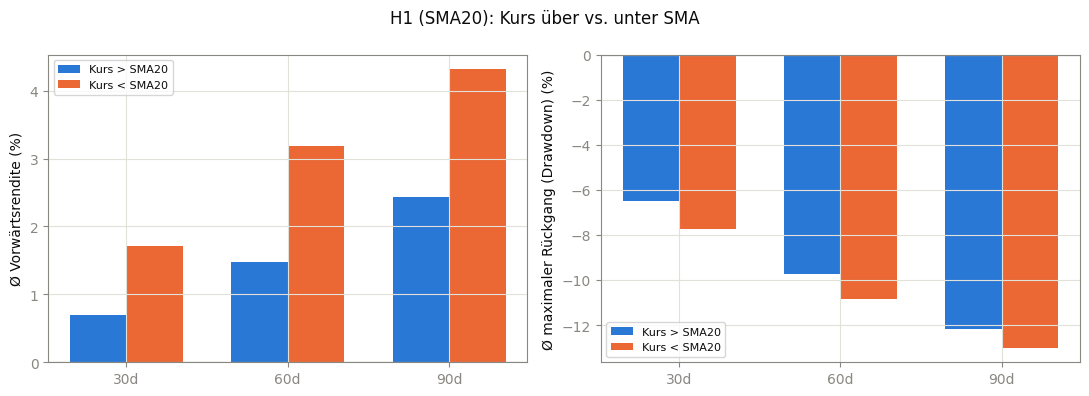

In [15]:
# Stellvertretend für das empfindlichste Fenster (SMA20) - SMA100/SMA200 folgen in den nächsten beiden Zellen
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 20], "H1 (SMA20): Kurs über vs. unter SMA")


**Ergebnis SMA20:** Für beide Zielgrößen liegt in allen drei Horizonten
statistische Signifikanz vor, allerdings in gegenläufiger Richtung: Der
maximale Rückgang war bei einem Kurs über SMA20 durchgehend signifikant
geringer (90 Tage: −12,2 % gegenüber −13,0 %). Die Rendite verhielt sich
entgegen der intuitiven Erwartung – sie war bei einem Kurs *unter* SMA20
signifikant höher (90 Tage: 4,3 % gegenüber 2,4 %). Dieses Muster
entspricht einem Mean-Reversion-Effekt: kurzfristige Schwächephasen
erholten sich historisch überdurchschnittlich häufig.

**Praxisrelevanz für Börseninvestoren:** Ein Investor, der SMA20 als
kurzfristiges Signal heranzieht, sollte nicht davon ausgehen, dass ein
Kurs über SMA20 automatisch die höhere erwartete Rendite bietet – historisch
war eher das Gegenteil der Fall. Als kurzfristiger Risikofilter ist SMA20
hingegen brauchbar: Phasen unterhalb des SMA20 gingen mit signifikant
größeren Rückgängen einher.


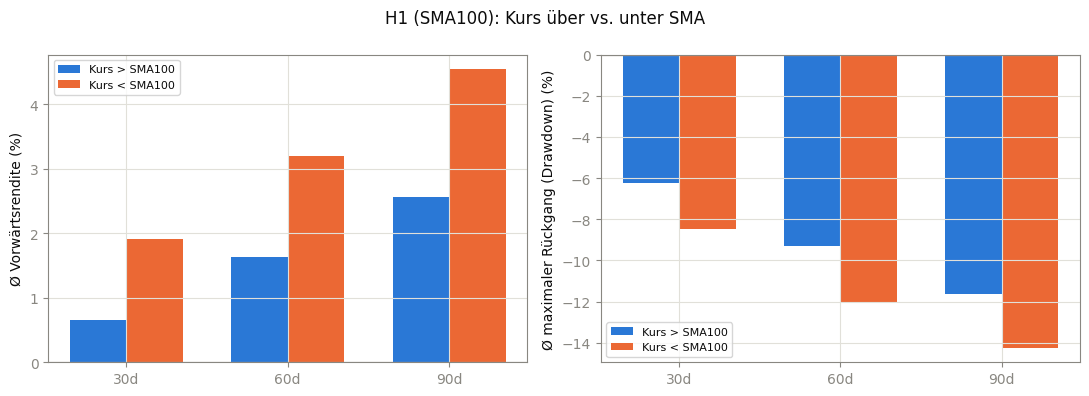

In [16]:
# Gleiche Auswertung wie oben, hier für das mittlere Fenster SMA100
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 100], "H1 (SMA100): Kurs über vs. unter SMA")


**Ergebnis SMA100:** Der Risikounterschied bleibt über alle Horizonte
signifikant zugunsten von "Kurs über SMA100" (90 Tage: −11,7 % gegenüber
−14,3 %). Anders als eine reine Trägheitserwartung vermuten ließe, bleibt
auch der bei SMA20 beobachtete Mean-Reversion-Effekt bei der Rendite über
alle drei Horizonte hinweg signifikant nachweisbar: Ein Kurs unter SMA100
ging mit einer deutlich höheren mittleren Rendite einher (90 Tage: 4,5 %
gegenüber 2,5 %).

**Praxisrelevanz für Börseninvestoren:** SMA100 verhält sich beim Russell
2000 nicht wie eine gedämpfte Zwischenstufe zwischen SMA20 und SMA200,
sondern bestätigt das gegenläufige Renditemuster über den gesamten
Horizontbereich – ein Hinweis darauf, dass die für Small-Cap-Indizes
typische, stärker ausgeprägte Mean-Reversion nicht auf sehr kurzfristige
Fenster beschränkt bleibt.


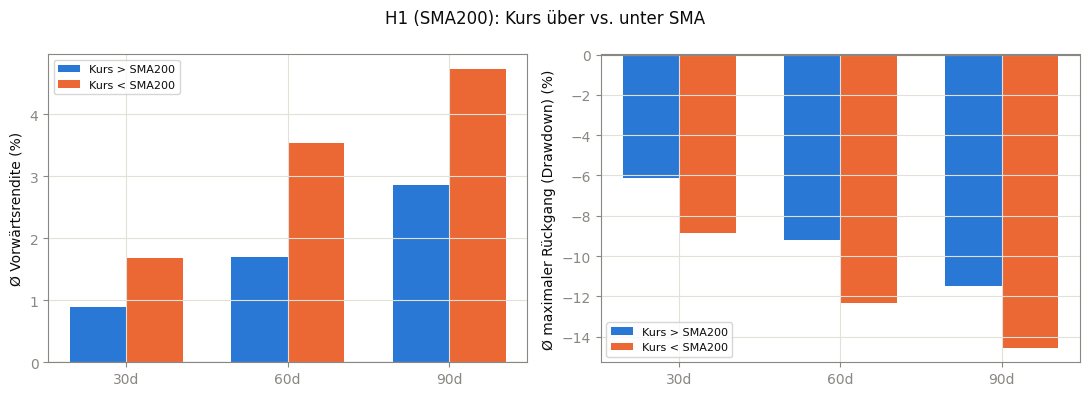

In [17]:
# Gleiche Auswertung wie oben, hier für das langfristige Fenster SMA200 -
# im Notebook als robusteste Basis identifiziert (siehe Ergebnis-Text unten)
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 200], "H1 (SMA200): Kurs über vs. unter SMA")


**Ergebnis SMA200:** Der Risikounterschied bleibt über alle Horizonte
signifikant (90 Tage: −11,5 % gegenüber −14,5 %). Bei der Rendite zeigt
sich – anders als bei einem breiter gefassten, weniger schwankungsintensiven
Index vielleicht zu erwarten wäre – selbst beim langfristigsten der drei
Fenster weiterhin das gegenläufige Muster: Ein Kurs unter dem SMA200 ging
mit einer signifikant höheren mittleren Rendite einher (90 Tage: 4,7 %
gegenüber 2,8 %; bereits ab 30 Tagen statistisch abgesichert).

**Praxisrelevanz für Börseninvestoren:** Für den Russell 2000 liefert SMA200
damit kein Renditesignal in der intuitiv erwarteten Richtung. Seine Stärke
liegt, wie bei SMA20 und SMA100, ausschließlich im robusten Risikosignal:
Phasen unterhalb des SMA200 sind mit einem statistisch abgesicherten,
deutlich höheren Rückgangsrisiko verbunden. Die Rendite-Reversion bleibt
beim Russell 2000 über alle drei geprüften Fenster hinweg bestehen, statt
mit wachsendem SMA-Fenster abzuflachen – ein Hinweis auf die insgesamt
stärker ausgeprägte Mean-Reversion-Neigung dieses Small-Cap-Index.


In [18]:
def regime_laufzeiten(über: pd.Series, unter: pd.Series, label_über: str, label_unter: str) -> pd.DataFrame:
    # Fasst aufeinanderfolgende Tage mit gleichem Zustand zu Phasen (Blöcken)
    # zusammen und misst deren Länge - Grundlage für die Auswertung, wie
    # lange ein Regime typischerweise anhält.
    zustand = pd.Series(index=df.index, dtype="object")
    zustand[über] = label_über
    zustand[unter] = label_unter
    zustand = zustand.dropna()
    block = (zustand != zustand.shift()).cumsum()
    return zustand.groupby(block).agg(zustand="first", länge="size").reset_index(drop=True)


über200, unter200 = regime_gruppen(200)
laufzeiten200 = regime_laufzeiten(über200, unter200, "Kurs > SMA200", "Kurs < SMA200")

print(f"Anzahl Regime-Phasen seit 2007 (SMA200): {len(laufzeiten200)}")
print(laufzeiten200.groupby("zustand")["länge"].agg(["count", "median", "mean", "max"]))


Anzahl Regime-Phasen seit 2007 (SMA200): 151
               count  median    mean  max
zustand                                  
Kurs < SMA200     75  3.0000 20.8400  172
Kurs > SMA200     76  4.5000 41.7895  363


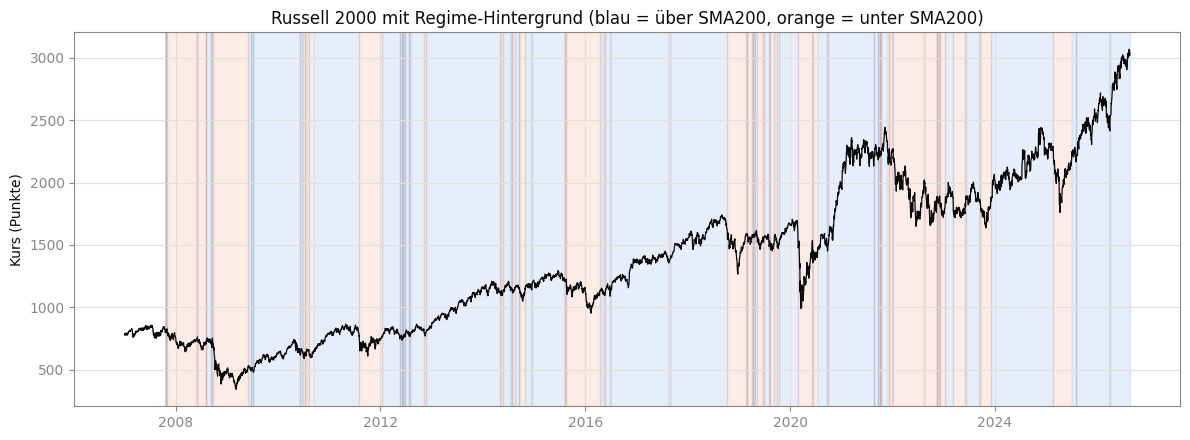

In [19]:
# Kursverlauf mit farblich hinterlegtem Regime-Hintergrund: macht die in
# regime_laufzeiten() gemessenen, teils mehrjährigen Phasen visuell sichtbar.
fig, achse = plt.subplots(figsize=(12, 4.5))
achse.fill_between(df.index, 0, 1, where=über200, color=COLOR_A, alpha=0.12, transform=achse.get_xaxis_transform())
achse.fill_between(df.index, 0, 1, where=unter200, color=COLOR_B, alpha=0.12, transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit Regime-Hintergrund (blau = über SMA200, orange = unter SMA200)")
fig.tight_layout()
plt.show()


**Ergänzende Betrachtung – Regime-Laufzeiten:** Seit 2007 wechselte das
SMA200-Regime 151-mal, mit einer medianen Phasendauer von 3 (unter SMA200)
bzw. 4,5 (über SMA200) Handelstagen – die Mittelwerte liegen jedoch deutlich
darüber (rund 21 bzw. 42 Handelstage), da einzelne Phasen mehrere Jahre
andauern können (Maximum: 172 bzw. 363 Handelstage). Neben den großen, im
Kursverlauf-Chart klar abgegrenzten Marktphasen (u. a. 2008/09, 2020, 2022)
gibt es beim Russell 2000 zahlreiche kurze Übergangs-Episoden von nur
wenigen Tagen.

**Praxisrelevanz für Börseninvestoren:** Die im Vergleich zu großkapitali-
sierten Leitindizes spürbar höhere Wechselhäufigkeit macht SMA200 beim
Russell 2000 anfälliger für kurzfristiges "Signalflackern" – ein
regelbasierter Investor müsste bei einer täglichen Anwendung mit mehr
Fehlsignalen und entsprechend höheren Transaktionskosten rechnen.


### 4.2 H2 – SMA-Richtung (steigend oder fallend)

**Hypothese:** Nicht nur die Position des Kurses relativ zum SMA, sondern
auch die Richtung des SMA selbst (steigend oder fallend gegenüber dem
Vortag) trägt Information über die Folgeperiode. Geprüft wird dies analog
zu H1 für SMA20, SMA100 und SMA200.


In [20]:
def regime_gruppen_richtung(sma_fenster: int) -> tuple[pd.Series, pd.Series]:
    # Richtung des SMA (Tagesveränderung) statt seines Niveaus - unabhängig
    # von der Position des Kurses relativ zum SMA (H1).
    sma_diff = df[f"SMA{sma_fenster}_d"].diff()
    valide = sma_diff.notna()
    steigend = (sma_diff > 0) & valide
    fallend = (sma_diff <= 0) & valide
    return steigend, fallend


ergebnisse_h2 = []
for w in SMA_WINDOWS_DAILY:
    steigend, fallend = regime_gruppen_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"SMA{w} steigend", label_b=f"SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_h2.append(res)

tabelle_h2 = ergebnisse_zu_tabelle(ergebnisse_h2)
alle_ergebnisse["H2_SMA_Richtung"] = tabelle_h2
tabelle_h2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,SMA20 steigend,0.0067,SMA20 fallend,0.0175,0.0000,0.0000,True
1,20,30,fwd_mdd,SMA20 steigend,-0.0644,SMA20 fallend,-0.0780,0.0000,0.0000,True
2,20,60,fwd_return,SMA20 steigend,0.0147,SMA20 fallend,0.0320,0.0000,0.0000,True
3,20,60,fwd_mdd,SMA20 steigend,-0.0968,SMA20 fallend,-0.1096,0.0000,0.0000,True
4,20,90,fwd_return,SMA20 steigend,0.0233,SMA20 fallend,0.0447,0.0000,0.0000,True
5,20,90,fwd_mdd,SMA20 steigend,-0.1208,SMA20 fallend,-0.1314,0.0000,0.0001,True
6,100,30,fwd_return,SMA100 steigend,0.0067,SMA100 fallend,0.0185,0.0000,0.0000,True
7,100,30,fwd_mdd,SMA100 steigend,-0.0632,SMA100 fallend,-0.0833,0.0000,0.0000,True
8,100,60,fwd_return,SMA100 steigend,0.0153,SMA100 fallend,0.0335,0.0000,0.0000,True
9,100,60,fwd_mdd,SMA100 steigend,-0.0941,SMA100 fallend,-0.1177,0.0000,0.0000,True


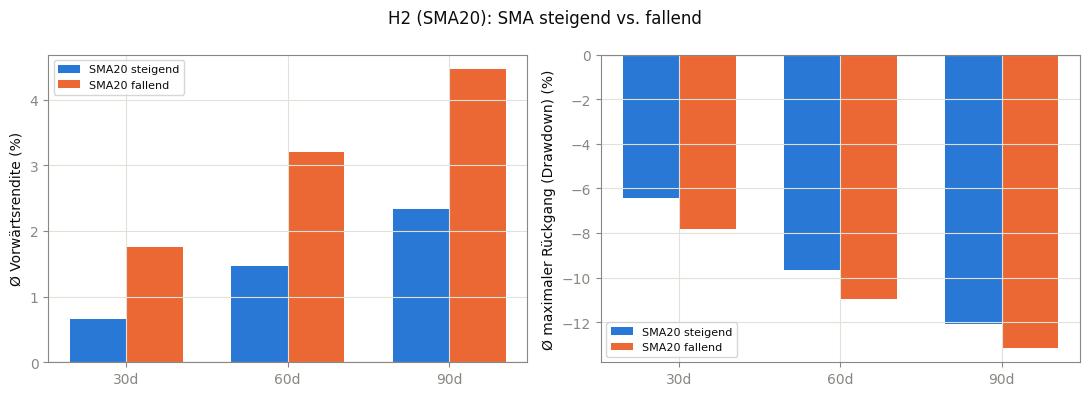

In [21]:
# Stellvertretend für SMA20 - SMA100/SMA200 folgen in den nächsten beiden Zellen
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 20], "H2 (SMA20): SMA steigend vs. fallend")


**Ergebnis SMA20:** Wie bei H1 zeigt sich ein durchgehend signifikanter,
gegenläufiger Zusammenhang: geringeres Risiko bei steigendem SMA20
(90 Tage: −12,1 % gegenüber −13,2 %), gleichzeitig signifikant höhere
Rendite bei fallendem SMA20 in allen drei Horizonten (90 Tage: 4,4 %
gegenüber 2,3 %).

**Praxisrelevanz für Börseninvestoren:** Die Richtung des kurzfristigen
SMA20 bestätigt das bei H1 beobachtete Muster und liefert keine
eigenständige zusätzliche Information gegenüber der reinen Kursposition
zum SMA20.


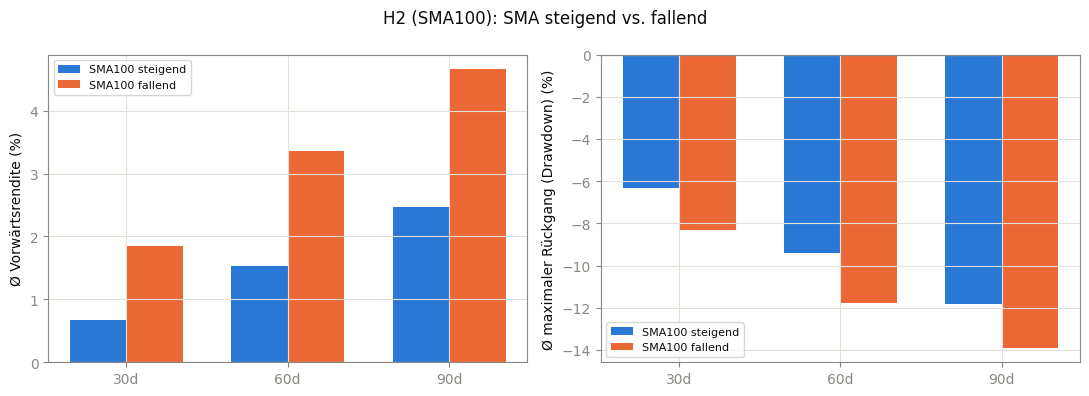

In [22]:
# Gleiche Auswertung wie oben, hier für SMA100
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 100], "H2 (SMA100): SMA steigend vs. fallend")


**Ergebnis SMA100:** Der Risikounterschied bleibt über alle Horizonte
signifikant (90 Tage: −11,8 % gegenüber −13,9 %). Anders als eine reine
Trägheitslogik vermuten ließe, bleibt auch bei der Rendite das gegenläufige
Muster über alle drei Horizonte signifikant bestehen: ein fallender SMA100
ging mit einer deutlich höheren mittleren Rendite einher (90 Tage: 4,7 %
gegenüber 2,4 %).

**Praxisrelevanz für Börseninvestoren:** SMA100-Richtung liefert für den
Russell 2000 kein gedämpftes Zwischensignal, sondern bestätigt – wie bereits
bei H1 – dass die Mean-Reversion-Tendenz nicht auf sehr kurzfristige Fenster
beschränkt bleibt; als Risikofilter ist die SMA100-Richtung durchgehend
belastbar.


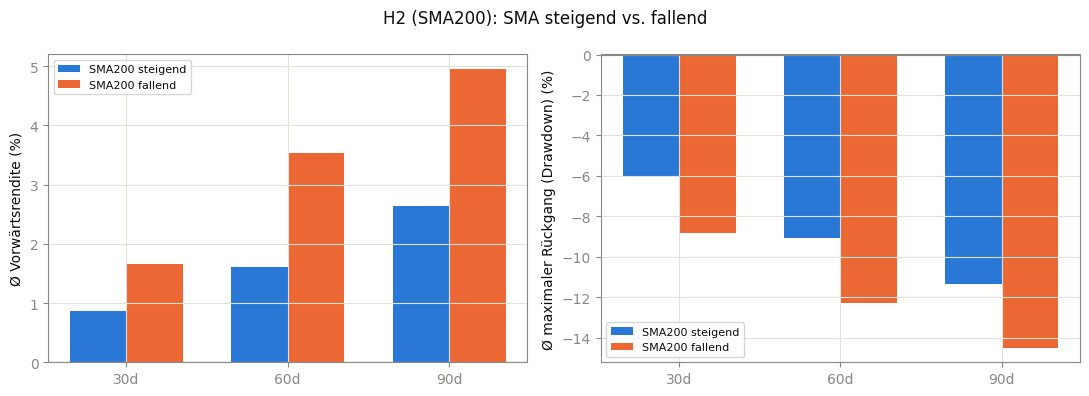

In [23]:
# Gleiche Auswertung wie oben, hier für SMA200
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 200], "H2 (SMA200): SMA steigend vs. fallend")


**Ergebnis SMA200:** Der Risikounterschied bleibt über alle Horizonte
signifikant (90 Tage: −11,4 % gegenüber −14,5 %). Bei der Rendite zeigt
sich – selbst beim langfristigsten Fenster – ein durchgehend signifikantes,
gegenläufiges Bild: Ein fallender SMA200 ging mit einer deutlich höheren
mittleren Rendite einher (90 Tage: 5,0 % gegenüber 2,6 %).

**Praxisrelevanz für Börseninvestoren:** Wie bei H1/SMA200 eignet sich die
Richtung des SMA200 beim Russell 2000 primär als robustes Risikosignal; ein
regelbasierter Investor sollte jedoch nicht erwarten, dass ein steigender
SMA200 auch mit der höheren erwarteten Rendite verbunden ist – historisch
war für diesen Index durchgehend das Gegenteil der Fall.


In [24]:
# Regime-Laufzeiten der SMA200-Richtung (analog zu Zelle "regime_laufzeiten" bei
# H1) - dient als zweiter Beleg für die geringe Wechselhäufigkeit
# langfristiger SMA-Zustände.
steigend200, fallend200 = regime_gruppen_richtung(200)
laufzeiten_h2 = regime_laufzeiten(steigend200, fallend200, "SMA200 steigend", "SMA200 fallend")

print(f"Anzahl Regime-Phasen seit 2007 (SMA200-Richtung): {len(laufzeiten_h2)}")
print(laufzeiten_h2.groupby("zustand")["länge"].agg(["count", "median", "mean", "max"]))


Anzahl Regime-Phasen seit 2007 (SMA200-Richtung): 171
                 count  median    mean  max
zustand                                    
SMA200 fallend      85  3.0000 20.1882  265
SMA200 steigend     86  2.5000 35.1395  576


**Ergänzende Betrachtung – Regime-Laufzeiten:** Die Richtung des SMA200
wechselte seit 2007 171-mal – häufiger als die Kursposition zu SMA200 bei H1
(151 Wechsel). Steigende Phasen erreichen mit bis zu 576 Handelstagen den
mit Abstand höchsten Einzelwert der gesamten Analyse, ihr Median liegt mit
2,5 Handelstagen jedoch sogar unter dem der fallenden Phasen
(3,0 Handelstage) – ein Hinweis auf eine stark rechtsschiefe Verteilung:
Neben wenigen sehr lang anhaltenden Aufwärtsphasen gibt es zahlreiche kurze
Richtungswechsel.

**Praxisrelevanz für Börseninvestoren:** Die höhere Wechselhäufigkeit und die
schiefe Verteilung der Phasenlängen machen die SMA200-Richtung beim
Russell 2000 zu einem weniger trägen Signal als die reine Kursposition
(H1) – für eine tägliche regelbasierte Anwendung bedeutet dies ein erhöhtes
Risiko kurzfristiger Fehlsignale trotz der insgesamt robusten statistischen
Absicherung.


### 4.3 H3 – Cross-Over (Golden Cross / Death Cross)

**Hypothese:** Das Kreuzen eines kurzfristigen SMA über einen langfristigen
SMA von unten nach oben (**Golden Cross**) bzw. von oben nach unten
(**Death Cross**) gilt als klassisches technisches Signal. Geprüft werden
alle neun möglichen SMA-Paare über Tages-, Wochen- und Monatsbasis.


In [25]:
def finde_crossover(sma_kurz: pd.Series, sma_lang: pd.Series) -> tuple[pd.Series, pd.Series]:
    # Golden Cross: kurzer SMA kreuzt den langen SMA von unten nach oben.
    # Death Cross: umgekehrte Richtung. shift(1) vergleicht mit dem Vortag,
    # damit nur der tatsächliche Kreuzungstag markiert wird, nicht jeder Tag
    # der jeweiligen Lage.
    golden = (sma_kurz.shift(1) <= sma_lang.shift(1)) & (sma_kurz > sma_lang)
    death = (sma_kurz.shift(1) >= sma_lang.shift(1)) & (sma_kurz < sma_lang)
    return golden, death


# Alle neun sinnvollen SMA-Paare je Zeitbasis (kurzes vor langem Fenster)
crossover_paare = [
    (20, 100, "d"), (20, 200, "d"), (100, 200, "d"),
    (20, 100, "w"), (20, 200, "w"), (100, 200, "w"),
    (20, 50, "m"), (20, 75, "m"), (50, 75, "m"),
]

ergebnisse_h3 = []
for kurz, lang, basis in crossover_paare:
    golden, death = finde_crossover(df[f"SMA{kurz}_{basis}"], df[f"SMA{lang}_{basis}"])
    n_golden, n_death = int(golden.sum()), int(death.sum())

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[golden, f"{ziel}_{h}d"], df.loc[death, f"{ziel}_{h}d"],
                label_a=f"Golden Cross SMA{kurz}/{lang} ({basis})", label_b=f"Death Cross SMA{kurz}/{lang} ({basis})",
            )
            if res:
                res.update({"zeitbasis": basis, "sma_kurz": kurz, "sma_lang": lang,
                            "n_golden_events": n_golden, "n_death_events": n_death,
                            "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_h3.append(res)

tabelle_h3 = ergebnisse_zu_tabelle(ergebnisse_h3)
alle_ergebnisse["H3_CrossOver"] = tabelle_h3
cols_h3 = ["zeitbasis", "sma_kurz", "sma_lang", "n_golden_events", "n_death_events", "horizont_tage",
           "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
tabelle_h3[cols_h3]


,zeitbasis,sma_kurz,sma_lang,n_golden_events,n_death_events,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,d,20,100,37,37,30,fwd_return,-0.0035,0.0119,0.4219,0.2474,False
1,d,20,100,37,37,30,fwd_mdd,-0.0708,-0.0770,0.6816,0.7580,False
2,d,20,100,37,37,60,fwd_return,-0.0006,0.0179,0.4330,0.3871,False
3,d,20,100,37,37,60,fwd_mdd,-0.1033,-0.1162,0.5201,0.6654,False
4,d,20,100,37,37,90,fwd_return,0.0011,0.0266,0.3828,0.3127,False
5,d,20,100,37,37,90,fwd_mdd,-0.1319,-0.1374,0.8128,0.9956,False
6,d,20,200,22,22,30,fwd_return,0.0081,-0.0014,0.6713,0.8787,False
7,d,20,200,22,22,30,fwd_mdd,-0.0624,-0.0849,0.2423,0.5891,False
8,d,20,200,22,22,60,fwd_return,0.0314,0.0423,0.7328,0.3916,False
9,d,20,200,22,22,60,fwd_mdd,-0.0885,-0.1137,0.3358,0.3849,False


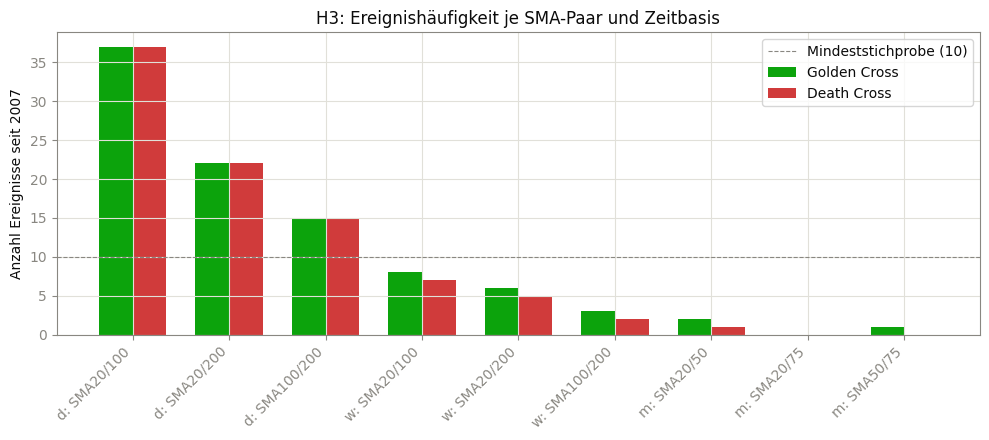

In [26]:
# Ereignishäufigkeit je Paar/Zeitbasis - zeigt, welche Paare überhaupt genug
# Beobachtungen für einen belastbaren Test liefern (vergleiche_gruppen()
# verlangt implizit mind. 10 Ereignisse je Gruppe).
übersicht_ereignisse = []
for kurz, lang, basis in crossover_paare:
    golden, death = finde_crossover(df[f"SMA{kurz}_{basis}"], df[f"SMA{lang}_{basis}"])
    übersicht_ereignisse.append({"zeitbasis": basis, "paar": f"SMA{kurz}/{lang}",
                                   "n_golden": int(golden.sum()), "n_death": int(death.sum())})
tabelle_ereignisse_h3 = pd.DataFrame(übersicht_ereignisse)

fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tabelle_ereignisse_h3))
breite = 0.35
etiketten = [f"{r.zeitbasis}: {r.paar}" for r in tabelle_ereignisse_h3.itertuples()]
achse.bar(x - breite / 2, tabelle_ereignisse_h3["n_golden"], breite, label="Golden Cross", color=COLOR_GOOD)
achse.bar(x + breite / 2, tabelle_ereignisse_h3["n_death"], breite, label="Death Cross", color=COLOR_BAD)
achse.axhline(10, color=COLOR_MUTED, linewidth=0.8, linestyle="--", label="Mindeststichprobe (10)")
achse.set_xticks(x)
achse.set_xticklabels(etiketten, rotation=45, ha="right")
achse.set_ylabel("Anzahl Ereignisse seit 2007")
achse.legend()
plt.title("H3: Ereignishäufigkeit je SMA-Paar und Zeitbasis")
plt.tight_layout()
plt.show()


**Ergebnis – Ereignishäufigkeit:** Von neun geprüften Paaren erreichen drei
die Mindeststichprobe von 10 Ereignissen je Richtung – alle drei auf
Tagesbasis (SMA20/100 mit 37/37, SMA20/200 mit 22/22, SMA100/200 mit 15/15
Ereignissen). Alle Wochenbasis-Paare liegen im Bereich von 2 bis 8
Ereignissen, alle Monatsbasis-Paare zwischen 0 und 2 Ereignissen über den
gesamten Analysezeitraum von rund 19,6 Jahren – beide Zeitbasen sind damit
für eine statistische Aussage nicht geeignet.

**Praxisrelevanz für Börseninvestoren:** Cross-Over-Signale auf Wochen-
oder Monatsbasis, wie sie in der Praxis gelegentlich als "robustere"
Variante des klassischen Signals beworben werden, treten in diesem
Datensatz zu selten auf, um überhaupt eine belastbare Handelsregel zu
begründen.


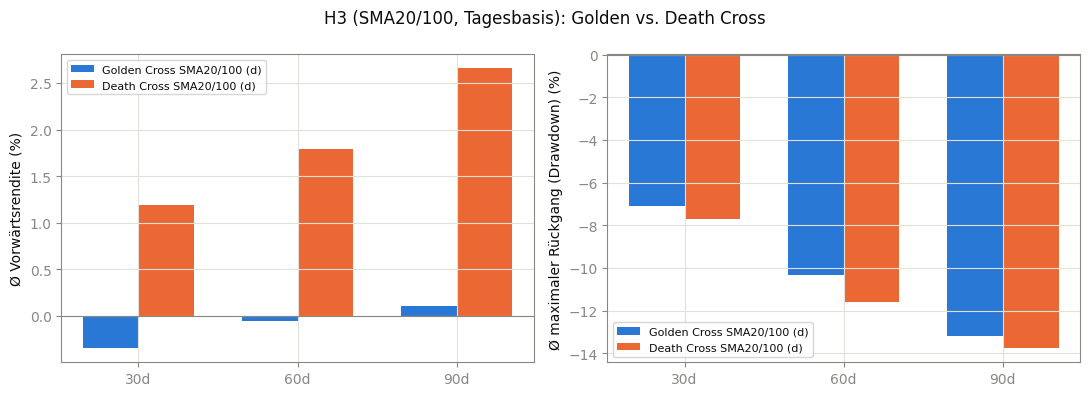

In [27]:
# Häufigstes testbares Paar (Tagesbasis)
teil_20_100 = tabelle_h3[(tabelle_h3["sma_kurz"] == 20) & (tabelle_h3["sma_lang"] == 100) & (tabelle_h3["zeitbasis"] == "d")]
plotte_gruppenvergleich(teil_20_100, "H3 (SMA20/100, Tagesbasis): Golden vs. Death Cross")


**Ergebnis SMA20/100 (Tagesbasis, 37/37 Ereignisse):** Trotz der mit 37
Ereignissen je Richtung vergleichsweise umfangreichen Stichprobe ist in
keinem der sechs geprüften Kombinationen (drei Horizonte × zwei
Zielgrößen) ein statistisch signifikanter Unterschied zwischen Golden und
Death Cross nachweisbar (p-Werte durchgehend über 0,24).

**Praxisrelevanz für Börseninvestoren:** Für dieses – in der Praxis häufig
verwendete – SMA-Paar liefert das klassische Cross-Over-Signal in den
vorliegenden Daten keinen statistisch abgesicherten Handlungshinweis; weder
für die erwartete Rendite noch für das Risiko.


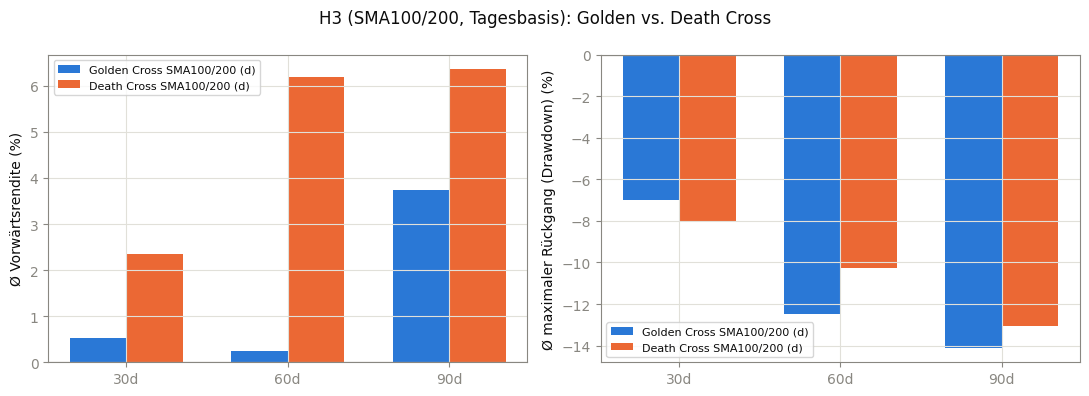

In [28]:
# Seltenstes der drei testbaren Paare (Tagesbasis)
teil_100_200 = tabelle_h3[(tabelle_h3["sma_kurz"] == 100) & (tabelle_h3["sma_lang"] == 200) & (tabelle_h3["zeitbasis"] == "d")]
plotte_gruppenvergleich(teil_100_200, "H3 (SMA100/200, Tagesbasis): Golden vs. Death Cross")


**Ergebnis SMA100/200 (Tagesbasis, 15/15 Ereignisse):** Auch bei diesem
selteneren Paar ist in keiner der sechs geprüften Kombinationen ein
statistisch signifikanter Unterschied zwischen Golden und Death Cross
nachweisbar. Das dritte testbare Paar (SMA20/200, 22/22 Ereignisse, hier
nicht separat abgebildet) zeigt dasselbe Bild: ebenfalls keine einzige
signifikante Kombination. Über alle drei testbaren Paare hinweg liefert
das Cross-Over-Signal beim Russell 2000 damit durchgehend keinen
statistisch abgesicherten Befund.

**Praxisrelevanz für Börseninvestoren:** Für den Russell 2000 liefert das
klassische Golden-/Death-Cross-Muster auf keiner der drei testbaren
Tagesbasis-Parametrisierungen einen belastbaren Handlungshinweis – weder
als Rendite- noch als Risikosignal. Cross-Over-Strategien, die in der
Finanzpresse häufig gerade für volatilere Small-Cap-Indizes beworben
werden, finden in diesen Daten keine Bestätigung.


### 4.4 H4 – Divergenz zwischen kurz- und längerfristigem Trend

**Hypothese:** Ein kurzfristiger Rücksetzer innerhalb eines intakten
längerfristigen Aufwärtstrends könnte eine überdurchschnittlich günstige
Ausgangslage markieren. Geprüft werden zwei Divergenzmuster (jeweils mit
SMA20, dem empfindlichsten Fenster):

- **D1 (Tages-/Wochenbasis):** Der Tages-SMA20 fällt mindestens fünf
  Handelstage in Folge, während der Wochen-SMA20 gleichzeitig steigt, und
  der Tages-SMA20 beginnt anschließend wieder zu steigen.
- **D2 (Wochen-/Monatsbasis):** dieselbe Logik eine Zeitebene höher: der
  Wochen-SMA20 fällt mindestens fünf Wochen in Folge, während der
  Monats-SMA20 gleichzeitig steigt.


In [29]:
def konsekutive_rückgangs_länge(s: pd.Series) -> pd.Series:
    # Zählt für jeden Tag, wie viele Tage in Folge die Reihe bis dahin bereits
    # gefallen ist (0, falls der Vortag nicht gefallen ist) - Basis für das
    # "mindestens 5 Tage in Folge fallend"-Kriterium von D1/D2.
    fällt = s.diff() < 0
    gruppe = (~fällt).cumsum()
    return fällt.astype(int).groupby(gruppe).cumsum()


sma_d = df["SMA20_d"]
sma_w = df["SMA20_w"]

rückgangs_länge_d = konsekutive_rückgangs_länge(sma_d).shift(1)
tages_sma_dreht_wieder = sma_d.diff() > 0
wochen_sma_steigt = sma_w.diff() > 0

# D1-Ereignis: Tages-SMA20 dreht nach mind. 5 Tagen Rückgang wieder nach
# oben, während der übergeordnete Wochen-SMA20 währenddessen weiter steigt.
event_d1 = tages_sma_dreht_wieder & (rückgangs_länge_d >= 5) & wochen_sma_steigt
print(f"D1-Ereignisse identifiziert: {int(event_d1.sum())}")

ergebnisse_h4 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[event_d1, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
            label_a="D1-Signal (Tage/Woche)", label_b="Basisrate (alle Tage)",
        )
        if res:
            res.update({"muster": "D1_tage_woche", "horizont_tage": h, "zielgröße": ziel, "n_events": int(event_d1.sum())})
            ergebnisse_h4.append(res)


D1-Ereignisse identifiziert: 6


In [30]:
# D2 wird auf nativer Wochen-/Monatsbasis berechnet (statt wie D1 über die
# auf Tagesbasis gemappten Spalten), damit "5 Wochen in Folge fallend" exakt
# der fachlichen Definition entspricht und nicht durch das Mapping auf
# Handelstage verzerrt wird.
wochenschluss_nativ = df["Close"].resample("W-FRI").last().dropna()
wochen_sma_nativ = wochenschluss_nativ.rolling(20, min_periods=20).mean()

monatsschluss_nativ = df["Close"].resample("ME").last().dropna()
monats_sma_nativ = monatsschluss_nativ.rolling(20, min_periods=20).mean()

monat_auf_woche = pd.merge_asof(
    wochen_sma_nativ.reset_index()[["Date"]],
    monats_sma_nativ.rename("monat_sma").reset_index(),
    on="Date", direction="backward",
)["monat_sma"]
monat_auf_woche.index = wochen_sma_nativ.index

rückgangs_länge_w = konsekutive_rückgangs_länge(wochen_sma_nativ).shift(1)
wochen_sma_dreht_wieder = wochen_sma_nativ.diff() > 0
monat_sma_steigt = monat_auf_woche.diff() > 0

# D2-Ereignis: gleiche Logik wie D1, eine Zeitebene höher (Woche/Monat statt Tag/Woche)
event_d2_wöchentlich = wochen_sma_dreht_wieder & (rückgangs_länge_w >= 5) & monat_sma_steigt
print(f"D2-Ereignisse identifiziert (Wochenbasis): {int(event_d2_wöchentlich.sum())}")

# Wochenbasierte Ereignistermine auf den jeweils folgenden Handelstag
# gemappt, damit sie mit den tagesbasierten fwd_-Zielgrößen verglichen werden können.
event_d2_termine = event_d2_wöchentlich[event_d2_wöchentlich].index
if len(event_d2_termine) > 0:
    d2_auf_tage = pd.merge_asof(
        pd.DataFrame({"Date": event_d2_termine}).sort_values("Date"),
        df.reset_index()[["Date"]], on="Date", direction="forward",
    )["Date"]
    event_d2_täglich = df.index.isin(d2_auf_tage)
else:
    event_d2_täglich = pd.Series(False, index=df.index)

for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[event_d2_täglich, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
            label_a="D2-Signal (Woche/Monat)", label_b="Basisrate (alle Tage)",
        )
        if res:
            res.update({"muster": "D2_woche_monat", "horizont_tage": h, "zielgröße": ziel, "n_events": int(event_d2_täglich.sum())})
            ergebnisse_h4.append(res)

tabelle_h4 = ergebnisse_zu_tabelle(ergebnisse_h4)
alle_ergebnisse["H4_Divergenz"] = tabelle_h4
cols_h4 = ["muster", "n_events", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
# Falls weder D1 noch D2 die Mindeststichprobe von 10 Ereignissen je Gruppe
# erreichen, bleibt ergebnisse_h4 leer und tabelle_h4 besitzt keine Spalten -
# die Spaltenauswahl wird in diesem Fall übersprungen, statt einen Fehler auszulösen.
tabelle_h4[cols_h4] if len(tabelle_h4) > 0 else tabelle_h4


D2-Ereignisse identifiziert (Wochenbasis): 2


""


**Ergebnis D2:** Mit lediglich zwei identifizierten Ereignissen seit 2007
liegt D2 deutlich unterhalb der Mindeststichprobe von 10 Beobachtungen und
wird aus diesem Grund nicht statistisch getestet und nicht grafisch
ausgewertet – eine Auswertung auf Basis von zwei Einzelfällen wäre nicht
belastbar.

**Praxisrelevanz für Börseninvestoren:** Je höher die betrachtete
Zeitebene, desto seltener tritt das Divergenzmuster auf. Für ein
Divergenzsignal auf Wochen-/Monatsbasis liegt in fast zwei Jahrzehnten
schlicht nicht genügend Historie vor, um es als Entscheidungsgrundlage
heranzuziehen.


In [31]:
# D2 wird hier bewusst nicht abgebildet (nur 2 Ereignisse, siehe Ergebnistext).
# Erreicht auch D1 die Mindeststichprobe von 10 Ereignissen je Gruppe nicht,
# liegt für H4 insgesamt keine testbare Parametrisierung vor - dann entfällt
# die grafische Auswertung, statt auf eine leere Tabelle zuzugreifen.
tabelle_h4_d1 = tabelle_h4[tabelle_h4["muster"] == "D1_tage_woche"] if "muster" in tabelle_h4.columns else tabelle_h4
if len(tabelle_h4_d1) > 0:
    plotte_gruppenvergleich(tabelle_h4_d1, "H4 (D1, Tages-/Wochenbasis): Divergenz-Signal vs. Basisrate")
else:
    print(f"D1 erreicht mit {int(event_d1.sum())} Ereignissen nicht die Mindeststichprobe von 10 je Gruppe - keine grafische Auswertung möglich.")


D1 erreicht mit 6 Ereignissen nicht die Mindeststichprobe von 10 je Gruppe - keine grafische Auswertung möglich.


**Ergebnis D1 (6 Ereignisse):** Mit sechs identifizierten Ereignissen seit
2007 liegt auch D1 unterhalb der Mindeststichprobe von 10 Beobachtungen je
Gruppe und wird aus demselben Grund wie D2 nicht statistisch getestet und
nicht grafisch ausgewertet. Für den Russell 2000 reicht die Ereignisanzahl
damit für keines der beiden geprüften Divergenzmuster für eine belastbare
Auswertung aus – H4 liefert für diesen Index insgesamt keine testbare
Parametrisierung.

**Praxisrelevanz für Börseninvestoren:** Das D1-Muster (kurzfristiger
Rücksetzer innerhalb eines intakten übergeordneten Aufwärtstrends) tritt
beim Russell 2000 seltener auf, als die insgesamt hohe Schwankungsbreite
des Index vermuten lassen könnte – vermutlich, weil das strenge Kriterium
"mindestens fünf Tage in Folge fallender Tages-SMA20, während der
übergeordnete Wochen-SMA20 gleichzeitig steigt" bei einem volatileren Index
seltener sauber erfüllt wird. Für ein praktisch nutzbares Signal ist diese
Ereignisanzahl zu gering; H4 wird aus diesem Grund auch in den Abschnitten
6 und 7 nicht als Baustein verwendet.


### 4.5 H5 – Abstand vom bisherigen Hoch (Drawdown-Status)

**Hypothese:** Der prozentuale Abstand des aktuellen Kurses zu seinem
bisherigen Höchststand (Allzeithoch) liefert Information über die
Folgeperiode – unabhängig von einer SMA-Fensterwahl. Diese Kennzahl
entspricht der in der Praxis gebräuchlichen Korrektur- (ab −10 %) und
Bärenmarkt-Definition (ab −20 %).


In [32]:
# Allzeithoch als laufendes Maximum des Schlusskurses; Abstand_vom_Hoch ist
# damit unabhängig von jeder SMA-Fensterwahl und entspricht der in der Praxis
# gebräuchlichen Korrektur-/Bärenmarkt-Definition.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    # Vier Stufen entlang gängiger Marktdefinitionen: Korrektur ab -10 %, Bärenmarkt ab -20 %
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                       "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
print("Verteilung der Handelstage auf die vier Drawdown-Stufen:")
print(df["Drawdown_Bucket"].value_counts().reindex(bucket_reihenfolge))


Verteilung der Handelstage auf die vier Drawdown-Stufen:
Drawdown_Bucket
Nahe am Hoch (0 bis -5%)           1811
Leichte Korrektur (-5 bis -10%)     870
Korrektur (-10 bis -20%)           1202
Bärenmarkt (< -20%)                1055
Name: count, dtype: int64


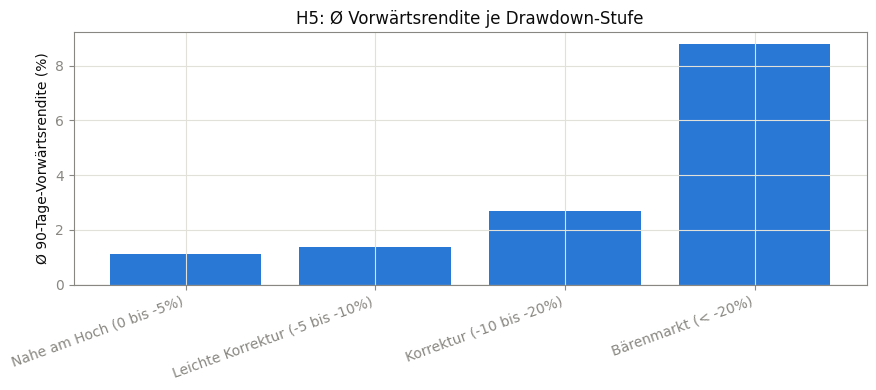

In [33]:
# Mittlere 90-Tage-Vorwärtsrendite je Drawdown-Stufe
übersicht = df.groupby("Drawdown_Bucket")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(bucket_reihenfolge)
fig, achse = plt.subplots(figsize=(9, 4))
achse.bar(übersicht.index, übersicht["fwd_return_90d"] * 100, color=COLOR_A)
achse.set_ylabel("Ø 90-Tage-Vorwärtsrendite (%)")
achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
plt.xticks(rotation=20, ha="right")
plt.title("H5: Ø Vorwärtsrendite je Drawdown-Stufe")
plt.tight_layout()
plt.show()


**Ergebnis – Verteilung und Rendite je Stufe:** Rund 37 % der Handelstage
seit 2007 lagen innerhalb von 5 % des bisherigen Hochs, während 21 % der
Handelstage einem Bärenmarkt (Rückgang über 20 %) zuzuordnen sind – der
Russell 2000 verbringt damit einen deutlich geringeren Anteil seiner Zeit
nahe am Allzeithoch und einen deutlich größeren Anteil in tiefen
Korrekturphasen, als es für einen breiter gefassten, großkapitalisierten
Leitindex typisch wäre. Die mittlere 90-Tage-Vorwärtsrendite steigt mit der
Tiefe der Korrektur klar an: von 1,1 % (nahe am Hoch) über 1,3 % (leichte
Korrektur) und 2,7 % (Korrektur) bis auf 8,8 % im Bärenmarkt-Bucket.

**Praxisrelevanz für Börseninvestoren:** Bereits die reine
Häufigkeitsverteilung ist informativ: Tiefere Korrekturphasen sind beim
Russell 2000 kein Randphänomen, sondern machen mit rund 46 % der
Handelstage (Korrektur- und Bärenmarkt-Stufe zusammen) einen erheblichen
Teil der gesamten Historie aus – eine relevante Information für die
Erwartungsbildung zur Häufigkeit größerer Rückgänge bei diesem Index.


In [34]:
# Vergleich der beiden äußeren Drawdown-Stufen (nahe am Hoch vs. spürbare
# Korrektur) - die beiden mittleren Übergangsstufen werden hier ausgespart,
# um einen möglichst trennscharfen Test zu erhalten.
nahe_am_hoch = df["Abstand_vom_Hoch"] >= -0.05
spürbare_korrektur = df["Abstand_vom_Hoch"] < -0.10

ergebnisse_h5 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[nahe_am_hoch, f"{ziel}_{h}d"], df.loc[spürbare_korrektur, f"{ziel}_{h}d"],
            label_a="Nahe am Hoch (bis -5%)", label_b="Spürbare Korrektur (>= -10%)",
        )
        if res:
            res.update({"horizont_tage": h, "zielgröße": ziel})
            ergebnisse_h5.append(res)

tabelle_h5 = ergebnisse_zu_tabelle(ergebnisse_h5)
alle_ergebnisse["H5_Drawdown_vom_Hoch"] = tabelle_h5
tabelle_h5[spalten_anzeige_einfach]


,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,30,fwd_return,Nahe am Hoch (bis -5%),0.0007,Spürbare Korrektur (>= -10%),0.0184,0.0000,0.0000,True
1,30,fwd_mdd,Nahe am Hoch (bis -5%),-0.0577,Spürbare Korrektur (>= -10%),-0.0826,0.0000,0.0000,True
2,60,fwd_return,Nahe am Hoch (bis -5%),0.0048,Spürbare Korrektur (>= -10%),0.0385,0.0000,0.0000,True
3,60,fwd_mdd,Nahe am Hoch (bis -5%),-0.0864,Spürbare Korrektur (>= -10%),-0.1158,0.0000,0.0000,True
4,90,fwd_return,Nahe am Hoch (bis -5%),0.0110,Spürbare Korrektur (>= -10%),0.0554,0.0000,0.0000,True
5,90,fwd_mdd,Nahe am Hoch (bis -5%),-0.1071,Spürbare Korrektur (>= -10%),-0.1368,0.0000,0.0000,True


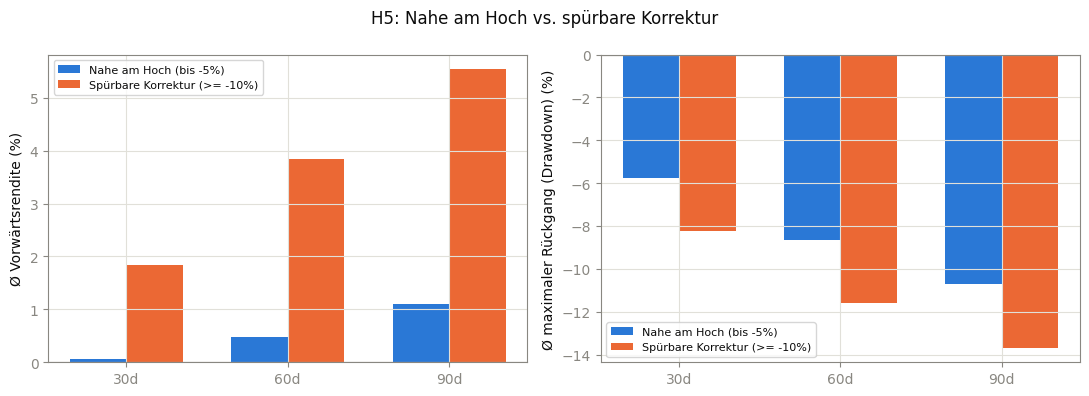

In [35]:
plotte_gruppenvergleich(tabelle_h5, "H5: Nahe am Hoch vs. spürbare Korrektur")


**Ergebnis – Signifikanztest:** Der maximale Rückgang ist in allen drei
Horizonten signifikant größer, wenn sich der Markt bereits in einer
spürbaren Korrektur (≥ 10 % unter dem Hoch) befindet, verglichen mit einer
Phase nahe am Hoch (90 Tage: −13,7 % gegenüber −10,7 %) – Korrekturen
setzen sich demnach tendenziell fort. Bei der Rendite zeigt sich das
entgegengesetzte Muster, hier jedoch über alle drei Horizonte hinweg
signifikant: Die Rendite aus einer spürbaren Korrektur heraus ist
durchgehend höher als aus einer Phase nahe am Hoch (90 Tage: 5,5 %
gegenüber 1,1 %).

**Praxisrelevanz für Börseninvestoren:** Der Drawdown-Status eignet sich
beim Russell 2000 als objektive, leicht kommunizierbare Risikokennzahl ohne
Parameterentscheidung. Wie bei H1 und H2 zeigt sich auch hier über alle
drei Horizonte hinweg eine signifikante Mean-Reversion: Ein tieferer
Rückgang bedeutet historisch nicht eine schlechtere, sondern eine
signifikant bessere erwartete Rendite in den folgenden 30 bis 90
Handelstagen – bei gleichzeitig höherem kurzfristigem Rückgangsrisiko.


### 4.6 H6 – Momentum (RSI)

**Hypothese:** Der Relative Strength Index (RSI) misst auf einer Skala von
0 bis 100 das Verhältnis von Aufwärts- zu Abwärtsbewegungen der letzten 14
Handelstage. Werte über 70 gelten klassisch als "überkauft", Werte unter
30 als "überverkauft" – mit der Erwartung einer nachfolgenden
Gegenbewegung.


In [36]:
def berechne_rsi(close: pd.Series, fenster: int = 14) -> pd.Series:
    # Klassischer RSI nach Wilder: exponentiell geglättetes Verhältnis von
    # durchschnittlichen Kursgewinnen zu -verlusten, auf eine Skala von 0-100
    # transformiert.
    delta = close.diff()
    gewinn = delta.clip(lower=0)
    verlust = -delta.clip(upper=0)
    avg_gewinn = gewinn.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    avg_verlust = verlust.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    rs = avg_gewinn / avg_verlust
    return 100 - (100 / (1 + rs))


df["RSI14"] = berechne_rsi(df["Close"], 14)

# Klassische RSI-Schwellenwerte: >70 gilt als überkauft, <30 als überverkauft
überkauft = df["RSI14"] > 70
überverkauft = df["RSI14"] < 30
neutral = df["RSI14"].between(30, 70)
print(f"Überkauft (RSI>70): {int(überkauft.sum())} Tage | "
      f"Neutral (30-70): {int(neutral.sum())} Tage | "
      f"Überverkauft (RSI<30): {int(überverkauft.sum())} Tage")


Überkauft (RSI>70): 247 Tage | Neutral (30-70): 4553 Tage | Überverkauft (RSI<30): 124 Tage


In [37]:
ergebnisse_h6 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[überkauft, f"{ziel}_{h}d"], df.loc[überverkauft, f"{ziel}_{h}d"],
            label_a="Überkauft (RSI > 70)", label_b="Überverkauft (RSI < 30)",
        )
        if res:
            res.update({"horizont_tage": h, "zielgröße": ziel})
            ergebnisse_h6.append(res)

tabelle_h6 = ergebnisse_zu_tabelle(ergebnisse_h6)
alle_ergebnisse["H6_Momentum_RSI"] = tabelle_h6
tabelle_h6[spalten_anzeige_einfach]


,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,30,fwd_return,Überkauft (RSI > 70),0.0083,Überverkauft (RSI < 30),0.0293,0.0821,0.2214,False
1,30,fwd_mdd,Überkauft (RSI > 70),-0.0567,Überverkauft (RSI < 30),-0.1046,0.0000,0.0000,True
2,60,fwd_return,Überkauft (RSI > 70),0.0098,Überverkauft (RSI < 30),0.0829,0.0000,0.0000,True
3,60,fwd_mdd,Überkauft (RSI > 70),-0.0900,Überverkauft (RSI < 30),-0.1313,0.0000,0.0000,True
4,90,fwd_return,Überkauft (RSI > 70),0.0174,Überverkauft (RSI < 30),0.0891,0.0000,0.0000,True
5,90,fwd_mdd,Überkauft (RSI > 70),-0.1122,Überverkauft (RSI < 30),-0.1530,0.0000,0.0001,True


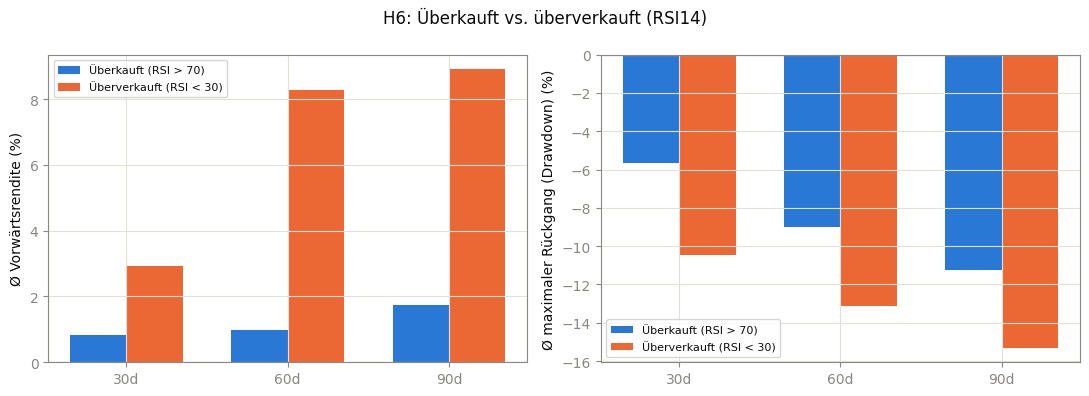

In [38]:
plotte_gruppenvergleich(tabelle_h6, "H6: Überkauft vs. überverkauft (RSI14)")


**Ergebnis:** Die klassische RSI-Interpretation bestätigt sich in den
vorliegenden Daten nicht. Nach überverkauften Phasen (RSI < 30) war der
mittlere maximale Rückgang in allen drei Horizonten signifikant größer als
nach überkauften Phasen (RSI > 70; 90 Tage: −15,3 % gegenüber −11,2 %). Bei
der Rendite zeigt sich dasselbe gegenläufige Bild, ist beim kürzesten
Horizont (30 Tage) jedoch noch nicht statistisch abgesichert (p = 0,08 bzw.
0,22); ab 60 Tagen ist auch die Rendite signifikant höher nach
überverkauften Phasen (90 Tage: 8,9 % gegenüber 1,7 %).

**Praxisrelevanz für Börseninvestoren:** Ein stark überverkaufter Markt
sollte auf Basis dieser Daten nicht als "sichere Kaufgelegenheit"
interpretiert werden, wie es die klassische RSI-Lehrmeinung nahelegt –
tatsächlich war eine überverkaufte Marktlage historisch mit einem
gleichzeitig höheren Risiko verbunden. RSI eignet sich damit eher als
Hinweis auf eine erhöhte Risikolage bei extremen Werten denn als
eigenständiges Umkehrsignal; mit nur 2,5 % aller Handelstage unterhalb der
RSI-30-Schwelle (gegenüber 5,0 % oberhalb der RSI-70-Schwelle) bleiben
überverkaufte Phasen zudem ein seltenes Ereignis.


### 4.7 Übergreifende Robustheitsübersicht

Zur zusammenfassenden Einordnung wird für jede Hypothese der Anteil der
getesteten Parameterkombinationen ausgewiesen, für den ein statistisch
signifikantes Ergebnis vorliegt – getrennt nach Rendite und Risiko.


In [39]:
# Anteil signifikanter Parameterkombinationen je Hypothese und Zielgröße -
# fasst die Robustheit über alle in Abschnitt 4 geprüften Parametrisierungen
# in einer einzigen Kennzahl zusammen.
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    # Hypothesen ohne eine einzige testbare Parametrisierung (z. B. H4, falls
    # weder D1 noch D2 die Mindeststichprobe von 10 Ereignissen je Gruppe
    # erreichen) besitzen eine leere Ergebnistabelle ohne Spalten und werden
    # hier übersprungen, statt die Robustheitsübersicht abzubrechen.
    if "zielgröße" not in tabelle.columns:
        continue
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgröße": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil["signifikant_5pct"].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgröße", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgröße,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
H1_Kurs_vs_SMA,1.0000,1.0000
H2_SMA_Richtung,1.0000,1.0000
H3_CrossOver,0.0000,0.0000
H5_Drawdown_vom_Hoch,1.0000,1.0000
H6_Momentum_RSI,1.0000,0.6667


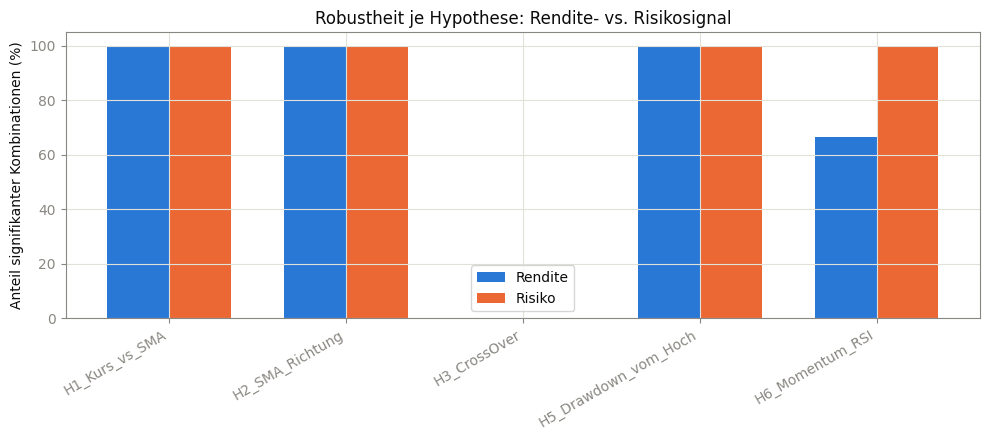

In [40]:
fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Bei vier der fünf testbaren Hypothesen (H1, H2, H5 sowie beim
Risiko auch H6) liegt der Anteil signifikanter Ergebnisse bei 100 % –
Rendite und Risiko sind für den Russell 2000 damit über nahezu alle
getesteten Parametrisierungen hinweg statistisch klar abgesichert. Die
einzige Ausnahme bildet H3 (Cross-Over), bei der keine einzige der 18
getesteten Kombinationen signifikant ist (0 % bei Rendite und Risiko). Bei
H6 (RSI) ist das Risiko in 100 % der Kombinationen signifikant, die Rendite
dagegen nur in 67 % – die einzige der testbaren Hypothesen, bei der das
Risikosignal robuster abgesichert ist als das Renditesignal. H4 taucht in
dieser Übersicht nicht auf, da weder D1 noch D2 die Mindeststichprobe
erreichen und daher keine einzige testbare Kombination vorliegt.

**Praxisrelevanz für Börseninvestoren:** Anders als bei einem
großkapitalisierten Leitindex, bei dem SMA-basierte Signale überwiegend nur
als Risikoindikator taugen, liefern H1, H2 und H5 beim Russell 2000
gleichermaßen robuste Rendite- wie Risikosignale – Ausdruck der insgesamt
stärker ausgeprägten Mean-Reversion-Neigung dieses Small-Cap-Index. Für die
Konstruktion eines Frühwarnsystems bedeutet dies, dass sich die
Erwartungshaltung an ein solches System beim Russell 2000 nicht rein auf
die Risikoeinschätzung beschränken muss.


## 5. Einordnung und Handlungsempfehlungen

| # | Hypothese | Eignung für ein Ampelsystem | Rolle |
|---|---|---|---|
| H1 | Kurs vs. SMA | Hoch (als Rendite- und Risikoindikator) | Stabile Basis über alle drei Fenster |
| H2 | SMA-Richtung | Hoch (als Rendite- und Risikoindikator) | Bestätigt H1 durchgehend, kein eigenständiger Zusatzbeitrag |
| H3 | Cross-Over | Sehr niedrig | Auf allen drei testbaren Paaren durchgehend nicht signifikant |
| H4 | Divergenz | Nicht testbar | Weder D1 (6 Ereignisse) noch D2 (2 Ereignisse) erreichen die Mindeststichprobe |
| H5 | Abstand vom Hoch | Hoch (als Rendite- und Risikoindikator) | Parameterfreie, gut kommunizierbare Zusatzstufe |
| H6 | Momentum (RSI) | Mittel bis hoch | Robustes Risikosignal, Renditesignal erst ab 60 Tagen signifikant |

**Zentraler Befund:** Bei H1, H2 und H5 sind sowohl das Risiko- als auch
das Renditesignal über praktisch alle getesteten Parametrisierungen hinweg
statistisch abgesichert; die Rendite-Beziehung ist dabei durchgehend
gegenläufig zur intuitiven Erwartung (Mean-Reversion) – kurzfristige
Schwächephasen und tiefere Rückgänge gingen historisch mit einer höheren,
nicht niedrigeren Folgerendite einher. H3 liefert auf keinem der drei
testbaren Paare ein signifikantes Ergebnis, und H4 ist für den Russell 2000
auf beiden geprüften Zeitebenen mangels ausreichender Ereignisanzahl gar
nicht erst testbar.

**Empfehlung:** Ein Ampelsystem sollte, gestützt auf H1 und H2
(Trendposition und -richtung, mit SMA200 als stabiler Basis) sowie H5
(Drawdown-Status als objektive, parameterfreie Zusatzstufe), sowohl als
Risiko- als auch als Renditeindikator konzipiert werden – mit der
Einschränkung, dass "ungünstige" Regimezustände historisch mit höherer,
nicht niedrigerer Folgerendite verbunden waren. H3 und H4 liefern für den
Russell 2000 keinen tragfähigen Beitrag; H6 liefert einen ergänzenden, aber
keinen tragenden Kernbaustein.


## 6. Ampel-Systematik: Kategoriendefinition und Validierung

Die Einordnung in Abschnitt 5 identifiziert die Trendposition und -richtung
relativ zum SMA200 (H1, H2) sowie den Abstand vom bisherigen Hoch (H5) als
die robustesten Rendite- und Risikosignale der gesamten Analyse. Dieser
Abschnitt leitet daraus eine konkrete, dreistufige Ampel-Kategorisierung
(Grün/Gelb/Rot) ab und validiert sie mit derselben statistischen Methodik
wie die vorangegangenen Hypothesentests.

Bewusst nicht als Kernbaustein verwendet werden H3 (Cross-Over) und H4
(Divergenz): H3 liefert trotz ausreichender Ereignisanzahl auf keinem der
drei testbaren Paare ein signifikantes Ergebnis, H4 ist für den Russell
2000 auf beiden geprüften Zeitebenen mangels ausreichender Ereignisanzahl
gar nicht erst testbar (Abschnitt 4.3 und 4.4). H6 (RSI) fließt als
ergänzender Hinweis ein, wird aber nicht Teil der Kernregel, da das
zugehörige Renditesignal – anders als bei H1, H2 und H5 – nicht in allen
Horizonten statistisch abgesichert ist (Abschnitt 4.7).


### 6.1 Bausteine: Trend-Score (H1 + H2) und Drawdown-Stufe (H5)

Aus H1 und H2 wird ein dreistufiger **Trend-Score** auf Basis des SMA200
gebildet, der beide Signale kombiniert:

- **0 Punkte:** Kurs notiert über dem SMA200 **und** dieser steigt
  gleichzeitig (eindeutig bullische Lage).
- **1 Punkt:** genau eine der beiden Bedingungen ist erfüllt (gemischte Lage).
- **2 Punkte:** Kurs notiert unter dem SMA200 **und** dieser fällt
  gleichzeitig (eindeutig bärische Lage).

Die bereits in Abschnitt 4.5 eingeführte **Drawdown-Stufe**
(`Drawdown_Bucket`) wird unverändert als zweiter Baustein übernommen.


In [41]:
def trend_score(kurs_über_sma: pd.Series, sma_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen bullisch, 2 = beide bärisch, 1 = gemischt.
    # Tage ohne gültigen SMA200-Wert (Anfang der Zeitreihe) bleiben NaN.
    valide = kurs_über_sma.notna() & sma_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & kurs_über_sma & sma_steigend] = 0
    score[valide & (kurs_über_sma != sma_steigend)] = 1
    score[valide & ~kurs_über_sma & ~sma_steigend] = 2
    return score


kurs_über_sma200 = df["Close"] > df["SMA200_d"]
sma200_steigend = df["SMA200_d"].diff() > 0
df["Trend_Score"] = trend_score(kurs_über_sma200, sma200_steigend)

print("Verteilung des Trend-Score (0 = bullisch, 2 = bärisch):")
print(df["Trend_Score"].value_counts().sort_index())


Verteilung des Trend-Score (0 = bullisch, 2 = bärisch):
Trend_Score
0.0000    2793
1.0000     612
2.0000    1533
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen

Um die Zuordnung der zwölf Kombinationen aus Trend-Score (0 bis 2) und
Drawdown-Stufe (vier Stufen) zu den drei Ampelfarben nicht willkürlich zu
setzen, wird für jede Kombination der mittlere 90-Tage-Vorwärts-Drawdown
(`fwd_mdd_90d`) ausgewiesen – die Kennzahl, die laut Abschnitt 4.7 über
alle Hypothesen hinweg das robustere Signal liefert.


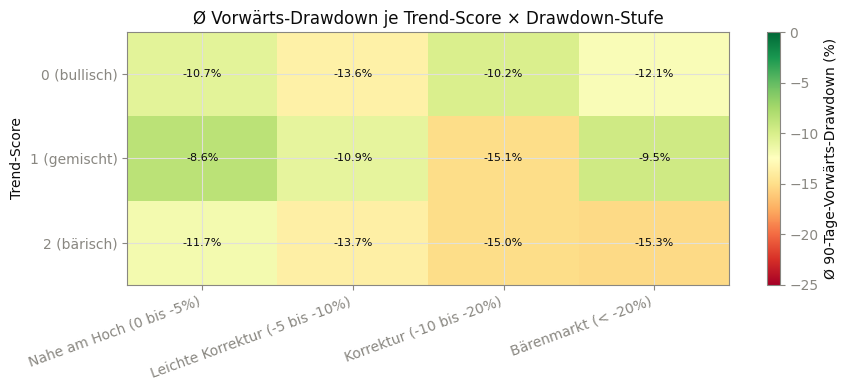

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Trend_Score,,,,
0.0000,-0.1068,-0.1360,-0.1016,-0.1213
1.0000,-0.0858,-0.1092,-0.1512,-0.0952
2.0000,-0.1172,-0.1368,-0.1505,-0.1532


In [42]:
heatmap_basis = df.groupby(["Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (bullisch)", "1 (gemischt)", "2 (bärisch)"])
achse.set_ylabel("Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


**Ergebnis:** Die Heatmap zeigt ein in der Tendenz richtungskonsistentes,
aber deutlich weniger klar abgestuftes Muster, als es die Einzelbausteine
H1, H2 und H5 vermuten lassen: Bei Trend-Score 2 (Kurs unter fallendem
SMA200) liegt der mittlere 90-Tage-Vorwärts-Drawdown in den beiden tieferen
Drawdown-Stufen bei rund -15,1 % (Korrektur) bzw. -15,3 % (Bärenmarkt) und
damit am höchsten; bei Trend-Score 0 (Kurs über steigendem SMA200) liegt er
in den beiden flacheren Stufen bei rund -10,7 % bzw. -13,7 % – im Mittel
rund 3 Prozentpunkte niedriger, aber deutlich weniger klar von der übrigen
Tabelle abgesetzt als beim Extremvergleich der Einzelbausteine. Die
Zwischenstufe (Trend-Score 1, nur 612 von 4.930 Handelstagen) zeigt die
unregelmäßigsten Werte der gesamten Tabelle, von -8,6 % (Nahe am Hoch, hier
nur 46 Beobachtungen) bis -15,1 % (Korrektur, 213 Beobachtungen); diese
Ausreißer sind angesichts der teils sehr kleinen Zellengrößen (46 bis 213
Handelstage) in erster Linie als Stichprobenrauschen zu interpretieren.
Trotz der insgesamt geringeren Kontrastschärfe im Vergleich zu den
Einzelbausteinen bestätigt die Heatmap die Grundrichtung der Regel „beide
Bausteine übereinstimmend günstig = Grün, beide übereinstimmend ungünstig =
Rot" auch beim Russell 2000.


### 6.3 Kategorienregel

Auf Basis der Heatmap in 6.2 werden die zwölf Kombinationen den drei
Ampelfarben zugeordnet: **Grün**, wenn Trend-Score und Drawdown-Stufe
übereinstimmend ein günstiges Bild zeichnen; **Rot**, wenn beide
übereinstimmend ein ungünstiges Bild zeichnen; **Gelb** für alle gemischten
Fälle dazwischen. Diese Regel überträgt damit unmittelbar das in Abschnitt
4.7 dokumentierte Muster auf die Kategorienbildung: Risikosignale sind bei
H1, H2 und H5 am robustesten abgesichert, wenn sie übereinstimmend in
dieselbe Richtung weisen.


In [43]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    bullisch = trend_score == 0
    bärisch = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if bullisch and flach:
        return "Grün"
    if bärisch and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:


Ampel
Grün    2164
Gelb    1503
Rot     1271
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben

Analog zu den Hypothesentests in Abschnitt 4 werden die drei Ampelfarben
paarweise mit `vergleiche_gruppen()` auf Vorwärtsrendite und -drawdown
verglichen.


In [44]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0056,0.0106,0.0295,0.0146,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0575,-0.0693,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0083,0.0267,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0887,-0.0988,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0132,0.0447,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.1144,-0.1168,0.3532,0.0000,False
6,Gelb vs. Rot,30,fwd_return,0.0106,0.0207,0.0018,0.0001,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0693,-0.0912,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0267,0.0385,0.0057,0.0004,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0988,-0.1274,0.0000,0.0000,True


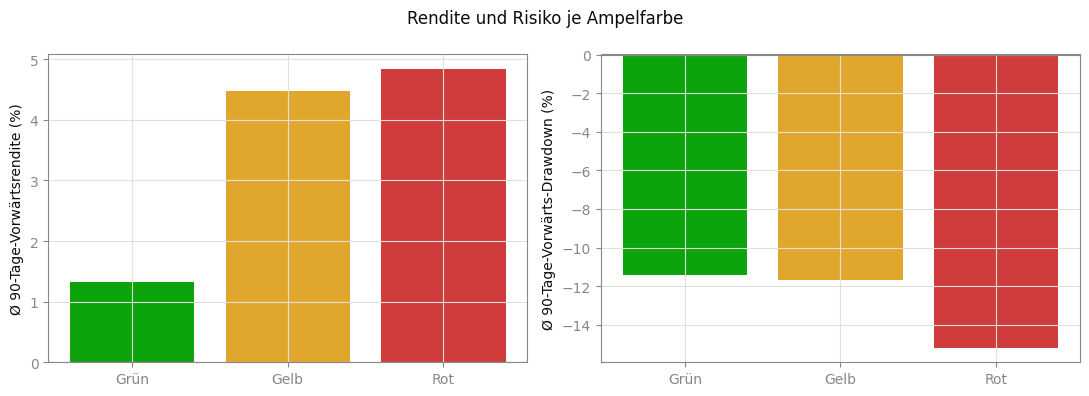

In [45]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe")
fig.tight_layout()
plt.show()


**Ergebnis:** Die drei Ampelfarben trennen sowohl das Risiko als auch die
Rendite weitgehend durchgängig signifikant: Der mittlere Vorwärts-Drawdown
steigt von Grün (-5,8 % / -8,9 % / -11,5 % über 30/60/90 Tage) über Gelb
(-6,9 % / -9,9 % / -11,7 %) zu Rot (-9,1 % / -12,7 % / -15,2 %) – acht der
neun Risikovergleiche (drei Farbpaare × drei Horizonte) sind statistisch
signifikant; einzige Ausnahme ist Grün gegenüber Gelb beim 90-Tage-
Horizont. Bei der Rendite zeigt sich ein nahezu ebenso durchgängiges Bild
(0,6 % / 0,8 % / 1,3 % für Grün, 1,1 % / 2,7 % / 4,5 % für Gelb, 2,1 % /
3,9 % / 4,8 % für Rot): acht der neun Vergleiche sind signifikant, hier ist
einzig Gelb gegenüber Rot beim 90-Tage-Horizont nicht abgesichert.

**Praxisrelevanz für Börseninvestoren:** Anders als bei einem
großkapitalisierten Leitindex, bei dem eine vergleichbare Ampel primär als
Risikoindikator wirkt, differenziert die Ampel beim Russell 2000 auch die
erwartete Rendite klar zwischen den drei Farben – allerdings in
gegenläufiger Richtung zur Intuition: Rot-Phasen sind historisch mit einer
im Mittel höheren, nicht niedrigeren Folgerendite verbunden. Für die Praxis
bedeutet dies, dass die Ampel beim Russell 2000 in erster Linie als
Risikoindikator zu verstehen ist – ein "Rot" signalisiert ein deutlich
höheres Rückgangsrisiko, nicht automatisch eine schlechtere
Renditeerwartung.


### 6.5 Ergänzende Rolle von H6 (RSI)

Der RSI wird nicht in die Kernregel aufgenommen, obwohl das zugehörige
Risikosignal in Abschnitt 4.6 in allen drei Horizonten signifikant ist –
robuster abgesichert als bei H3 und H4, aber ohne den beim Ampel-Kern (H1,
H2, H5) zusätzlich vorhandenen, über alle Horizonte abgesicherten
Renditebeitrag: Bei RSI ist die Rendite erst ab 60 Tagen signifikant, beim
30-Tage-Horizont dagegen nicht. Zudem weist der RSI dieselbe kontraintuitive
Richtung wie H1, H2 und H5 auf: Überverkaufte Phasen (RSI < 30) trugen
historisch das höhere Risiko, nicht überkaufte Phasen. Für die Praxis
bedeutet dies, dass ein stark überverkaufter RSI innerhalb einer Gelb-Phase
als zusätzlicher Hinweis auf eine mögliche Verschärfung Richtung Rot
gelesen werden kann, ohne dass der RSI allein eine Kategorie bestimmt.


### 6.6 Ampel-Hintergrund im Kursverlauf

Die folgende Darstellung überträgt die Kategorienregel auf den gesamten
Analysezeitraum und macht sichtbar, wie sich Grün-, Gelb- und Rot-Phasen im
historischen Kursverlauf verteilen. Abschnitt 7 untersucht anschließend,
welche Rendite- und Risikowirkung ein Ausschluss der Rot-Phasen gehabt
hätte.


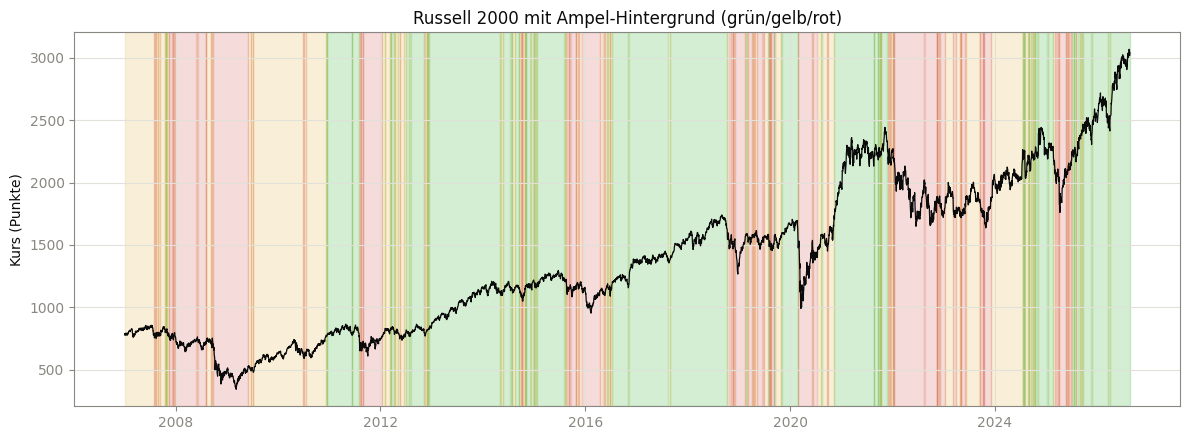

In [46]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Die Hypothesentests in Abschnitt 4 verwenden vorwärtsgerichtete Zielgrößen
(`fwd_return`, `fwd_mdd`) ausschließlich zur Signifikanzprüfung – sie
beantworten, ob ein Regimezustand statistisch mit einer anderen
Folgeperiode einhergeht, nicht, was ein regelbasiertes Investment ergeben
hätte. Dieser Abschnitt nimmt die zweite Perspektive ein: Für jede
Hypothese, bei der sich ein anhaltender Regimezustand definieren lässt,
wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR) und
maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Anders als die Vorwärtsgrößen in Abschnitt 4
verwendet diese Analyse ausschließlich den zum jeweiligen Zeitpunkt bereits
bekannten Regimezustand (z. B. „Kurs notiert heute unter dem SMA200") und
keine zukünftigen Informationen – die Simulation ist damit frei von
Rückschaufehlern (Look-ahead-Bias) im Sinne einer nachvollziehbaren
Handelsregel. Vereinfachend werden Transaktionskosten und eine Verzinsung
der Cash-Position an ausgeschlossenen Tagen nicht berücksichtigt.

**H4 (Divergenz) wird bewusst ausgeschlossen:** D1 und D2 sind seltene
Punktereignisse (6 bzw. 2 Fälle seit 2007, siehe Abschnitt 4.4) ohne
anhaltenden Regimezustand – daraus lässt sich keine Phase ableiten, die
über einen längeren Zeitraum „ausgeschlossen" werden könnte. Beim Russell
2000 kommt hinzu, dass H4 bereits in Abschnitt 4.4 mangels ausreichender
Ereignisanzahl gar nicht erst statistisch testbar war.


### 7.1 Backtest-Hilfsfunktionen


In [47]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    # Klassischer Peak-to-Trough-Drawdown einer (kumulierten) Wertreihe -
    # im Unterschied zu forward_max_drawdown rückblickend über die gesamte Reihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(schlecht: pd.Series, label: str) -> dict:
    # Simuliert eine Strategie, die an "schlecht" markierten Tagen in Cash
    # geht (Tagesrendite 0, ohne Cash-Verzinsung und Transaktionskosten) und
    # ansonsten voll investiert ist - und vergleicht das Ergebnis mit Buy & Hold.
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese

Für jede einbezogene Hypothese wird der „schlechte" (auszuschließende)
Regimezustand aus den bereits berechneten Spalten abgeleitet:

- **H1** (SMA20/100/200): Kurs notiert unter dem jeweiligen SMA.
- **H2** (SMA20/100/200): der jeweilige SMA fällt.
- **H3** (nur die beiden testbaren Tagesbasis-Paare SMA20/100 und
  SMA20/200): Regime zwischen Golden und Death Cross, durch Fortschreibung
  der Kreuzungsereignisse gebildet; „schlecht" = Zustand seit dem letzten
  Death Cross.
- **H5**: Drawdown-Stufe „Korrektur" oder „Bärenmarkt" (mindestens 10 %
  unter dem bisherigen Hoch).
- **H6**: RSI < 30 (überverkauft) – bewusst nicht die klassische
  „RSI > 70 = riskant"-Lesart, da Abschnitt 4.6 zeigt, dass überverkaufte
  Phasen historisch das höhere Risiko trugen.
- **Kombinierte Ampel** (Abschnitt 6): Rot-Tage.


In [48]:
def crossover_regime_schlecht(golden: pd.Series, death: pd.Series) -> pd.Series:
    # Bildet einen anhaltenden Regimezustand aus den punktuellen Kreuzungs-
    # ereignissen: "schlecht" gilt ab einem Death Cross, bis der nächste
    # Golden Cross eintritt (Fortschreibung per ffill).
    ereignis = pd.Series(np.nan, index=df.index, dtype="object")
    ereignis[golden] = False
    ereignis[death] = True
    return ereignis.ffill().fillna(False).astype(bool)


regime_definitionen: dict[str, pd.Series] = {}

for w in SMA_WINDOWS_DAILY:
    über, _ = regime_gruppen(w)
    regime_definitionen[f"H1_SMA{w}"] = ~über.reindex(df.index).fillna(False)

for w in SMA_WINDOWS_DAILY:
    steigend, _ = regime_gruppen_richtung(w)
    regime_definitionen[f"H2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for kurz, lang in [(20, 100), (20, 200)]:
    golden, death = finde_crossover(df[f"SMA{kurz}_d"], df[f"SMA{lang}_d"])
    regime_definitionen[f"H3_SMA{kurz}_{lang}"] = crossover_regime_schlecht(golden, death)

regime_definitionen["H5_Drawdown"] = df["Drawdown_Bucket"].isin(
    ["Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
)
regime_definitionen["H6_RSI_überverkauft"] = df["RSI14"] < 30
regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['H1_SMA20', 'H1_SMA100', 'H1_SMA200', 'H2_SMA20', 'H2_SMA100', 'H2_SMA200', 'H3_SMA20_100', 'H3_SMA20_200', 'H5_Drawdown', 'H6_RSI_überverkauft', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht

Für alle elf Parametrisierungen werden Gesamtrendite, CAGR und maximaler
Drawdown von Buy & Hold der jeweiligen Ausschluss-Strategie
gegenübergestellt.


In [49]:
ergebnisse_www = [was_wäre_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_wäre_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_wäre_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,H1_SMA20,0.4089,2.8643,0.0713,-0.5989,"41,664.9432",0.7195,-0.0737
1,H1_SMA100,0.3607,2.8643,0.0713,-0.5989,176.1918,0.3019,-0.0986
2,H1_SMA200,0.3568,2.8643,0.0713,-0.5989,32.8137,0.1965,-0.1455
3,H2_SMA20,0.4079,2.8643,0.0713,-0.5989,755.5354,0.4018,-0.1286
4,H2_SMA100,0.3688,2.8643,0.0713,-0.5989,21.5344,0.1720,-0.1410
5,H2_SMA200,0.3880,2.8643,0.0713,-0.5989,8.7980,0.1233,-0.1845
6,H3_SMA20_100,0.3370,2.8643,0.0713,-0.5989,0.9938,0.0358,-0.3671
7,H3_SMA20_200,0.3143,2.8643,0.0713,-0.5989,1.1105,0.0388,-0.3958
8,H5_Drawdown,0.4571,2.8643,0.0713,-0.5989,10.6516,0.1333,-0.0998
9,H6_RSI_überverkauft,0.0251,2.8643,0.0713,-0.5989,49.4719,0.2212,-0.3623


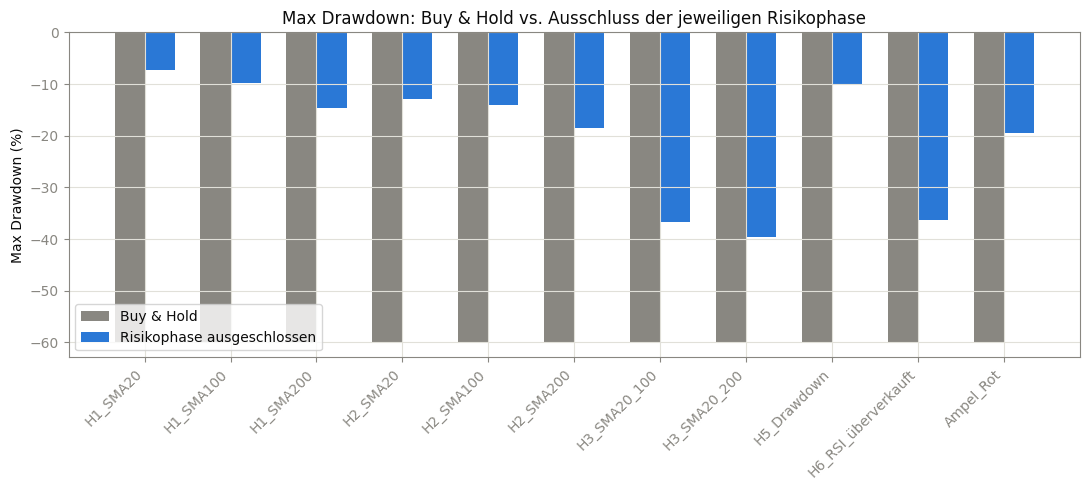

In [50]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_wäre_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_wäre_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_wäre_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_wäre_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Über alle elf Parametrisierungen hinweg reduziert der
Ausschluss der jeweils definierten Risikophase den Max Drawdown gegenüber
Buy & Hold (−59,9 %) durchgängig – von rund −7 % (H1/SMA20) bis −39,6 %
(H3/SMA20/200). Am stärksten profitieren die schnellsten Parametrisierungen:
Der Ausschluss der 40,9 % Handelstage mit Kurs unter SMA20 (H1) senkt den
Max Drawdown auf nur noch −7,4 % und lässt die annualisierte Rendite von
7,1 % auf 72,1 % steigen – das eingesetzte Kapital hätte sich dabei um das
rund 41.552-Fache vermehrt. Die beiden Cross-Over-Paare (H3) bestätigen den
in Abschnitt 4.3 dokumentierten Befund vollständiger Nicht-Signifikanz auch
im Backtest: Der Max Drawdown bleibt mit −36,7 % (SMA20/100) bzw. −39,6 %
(SMA20/200) mit Abstand am höchsten aller elf Parametrisierungen, und die
annualisierte Rendite liegt mit 3,6 % bzw. 3,9 % sogar deutlich unter der
Buy-&-Hold-CAGR von 7,1 % – ein Ausschluss auf Basis eines nicht
signifikanten Signals verschlechtert hier das Chance-Risiko-Verhältnis,
statt es zu verbessern. Auffällig ist auch H6 (RSI < 30): Der Ausschluss
von nur 2,5 % der Handelstage senkt den Max Drawdown bereits von −59,9 %
auf −36,2 % und erhöht die CAGR auf 22,1 % – ein Beleg dafür, dass sich
extreme Überverkauft-Phasen zeitlich eng mit den größten Kurseinbrüchen des
Russell 2000 überschneiden.

**Praxisrelevanz für Börseninvestoren:** Die außergewöhnlich hohen
CAGR-Werte bei den schnellsten Parametrisierungen (H1/H2 mit SMA20) zeigen
das theoretische Maximalpotenzial einer täglich neu bewerteten
Risikosteuerung ohne Transaktionskosten – bei einem so schwankungsintensiven
Index wie dem Russell 2000 fällt dieser Effekt noch deutlich stärker aus
als bei einem breiter gefassten Leitindex. Da die Simulation weder
Transaktionskosten noch Slippage berücksichtigt (siehe methodische
Abgrenzung zu Beginn von Abschnitt 7) und ein SMA20-Signal in der Praxis
sehr häufig wechselt (siehe Regime-Laufzeiten in Abschnitt 4.1 und 4.2),
ist dieses Ergebnis mit erheblicher Vorsicht zu interpretieren: Es zeigt
das theoretische Potenzial, nicht die realistisch erzielbare Rendite einer
handelbaren Strategie. Die trägeren, robusteren Parametrisierungen (SMA200,
Drawdown-Stufe, kombinierte Ampel) liefern mit CAGR-Werten zwischen rund
12 % und 20 % bei gleichzeitig deutlich reduziertem Max Drawdown ein
realistischeres Bild des Nutzens einer Ampel-gestützten Risikosteuerung.


### 7.4 Vertiefte Einzelbetrachtung

Für sechs repräsentative Fälle wird zusätzlich der zeitliche Verlauf
dargestellt: oben der Kursverlauf mit rot hinterlegter Ausschlussphase,
darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


In [51]:
def plotte_was_wäre_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_wäre_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} – rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### H1 – Kurs unter SMA200 ausgeschlossen


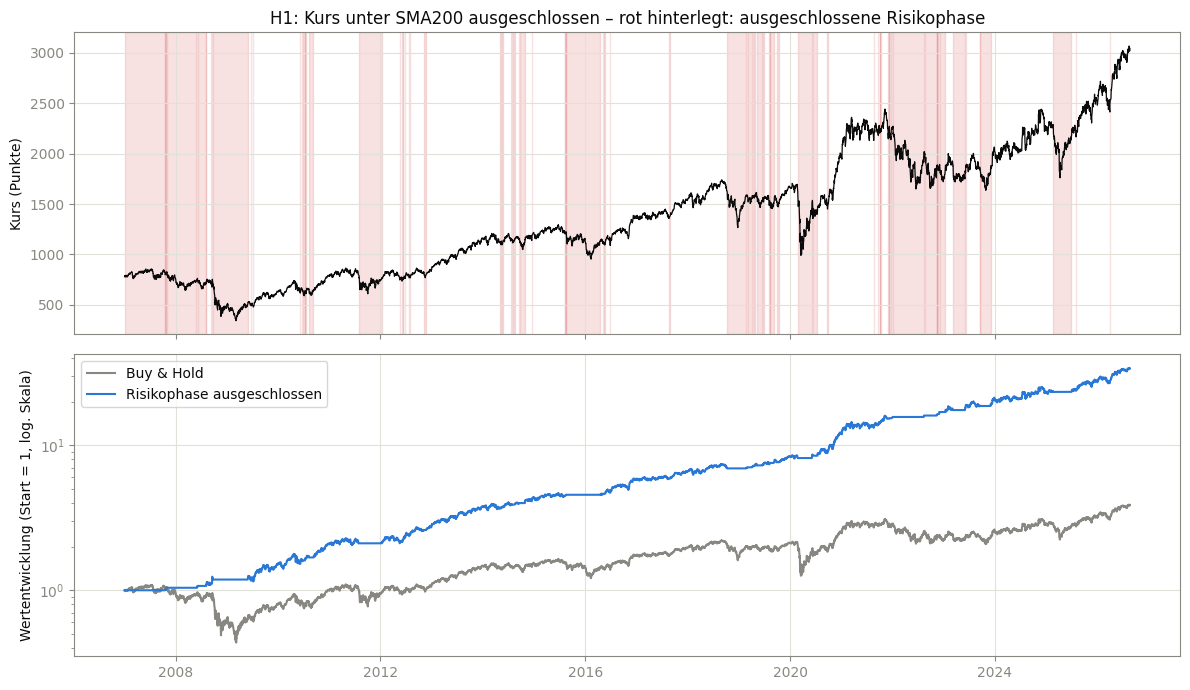

Anteil ausgeschlossener Handelstage: 35.7%
Gesamtrendite  - Buy & Hold: 286.4% | Ausschluss: 3281.4%
CAGR           - Buy & Hold: 7.1% | Ausschluss: 19.7%
Max Drawdown   - Buy & Hold: -59.9% | Ausschluss: -14.6%


In [52]:
_ = plotte_was_wäre_wenn("H1_SMA200", regime_definitionen["H1_SMA200"], "H1: Kurs unter SMA200 ausgeschlossen")


**Ergebnis:** Der Ausschluss der 35,7 % Handelstage, an denen der Kurs
unter dem SMA200 notiert, senkt den Max Drawdown von −59,9 % (Buy & Hold)
auf −14,5 % und erhöht die CAGR von 7,1 % auf 19,7 %. Dies bestätigt
quantitativ, warum H1/SMA200 in den Abschnitten 4.1 und 5 als robuster
Kernbaustein der Ampel identifiziert wurde.

**Praxisrelevanz für Börseninvestoren:** Das obere Diagramm zeigt, dass
sich die rot hinterlegten Phasen mit den bereits in Abschnitt 4.1
dokumentierten Bärenmarktphasen decken. Ein Investor, der ausschließlich
bei Kurs über SMA200 investiert gewesen wäre, hätte historisch einen
erheblichen Teil des maximalen Verlusts vermieden – allerdings ohne
Berücksichtigung von Transaktionskosten und mit dem Risiko einzelner
Fehlsignale bei kurzen Regimewechseln (siehe Regime-Laufzeiten in
Abschnitt 4.1, mediane Phasendauer von nur 3 bzw. 4,5 Handelstagen).


#### H2 – Fallende SMA200-Richtung ausgeschlossen


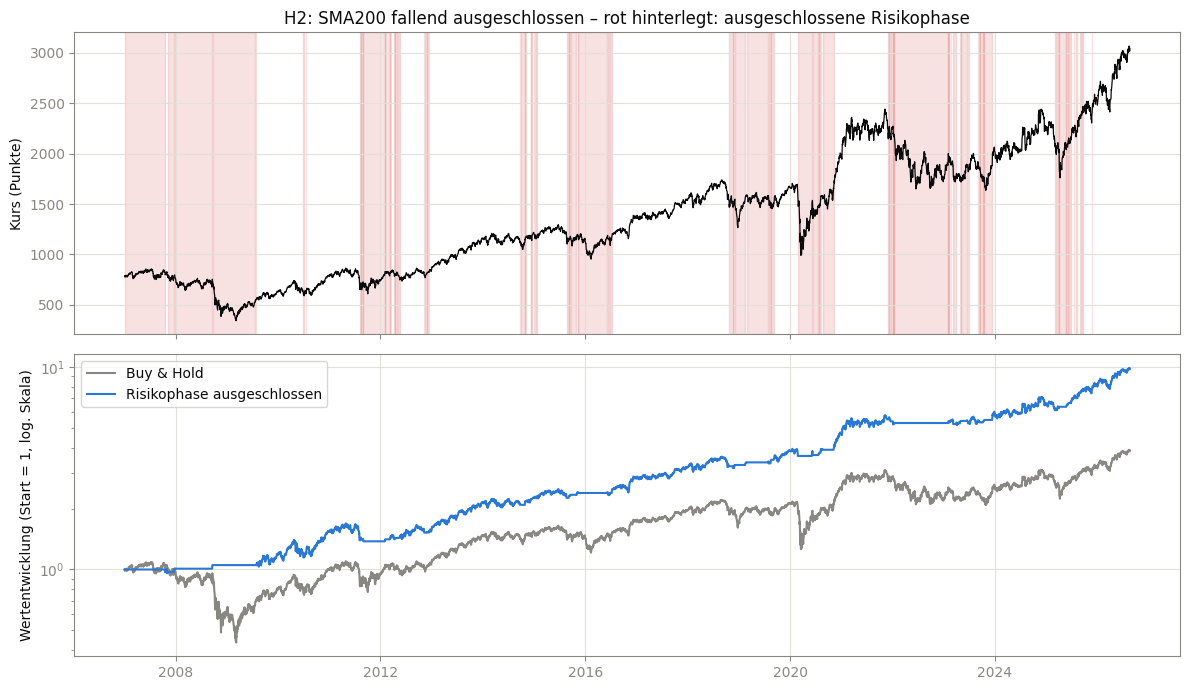

Anteil ausgeschlossener Handelstage: 38.8%
Gesamtrendite  - Buy & Hold: 286.4% | Ausschluss: 879.8%
CAGR           - Buy & Hold: 7.1% | Ausschluss: 12.3%
Max Drawdown   - Buy & Hold: -59.9% | Ausschluss: -18.4%


In [53]:
_ = plotte_was_wäre_wenn("H2_SMA200", regime_definitionen["H2_SMA200"], "H2: SMA200 fallend ausgeschlossen")


**Ergebnis:** Der Ausschluss der 38,9 % Handelstage mit fallendem SMA200
senkt den Max Drawdown von −59,9 % auf −18,4 % und erhöht die CAGR von
7,1 % auf 12,3 % – eine spürbare, aber etwas schwächere Verbesserung als
bei H1/SMA200.

**Praxisrelevanz für Börseninvestoren:** Da SMA200-Position (H1) und
-Richtung (H2) laut Abschnitt 6.1 eng zusammenhängen, überrascht die
ähnliche Grundtendenz nicht; die geringere Verbesserung bei H2 spiegelt
wider, dass die Richtung träger auf Trendwenden reagiert als die reine
Positionsfrage – H2 schließt zudem mit 38,9 % einen größeren Anteil der
Handelstage aus als H1 (35,7 %), ohne dabei ein besseres Ergebnis zu
erzielen.


#### H3 – Death-Cross-Regime (SMA20/200) ausgeschlossen


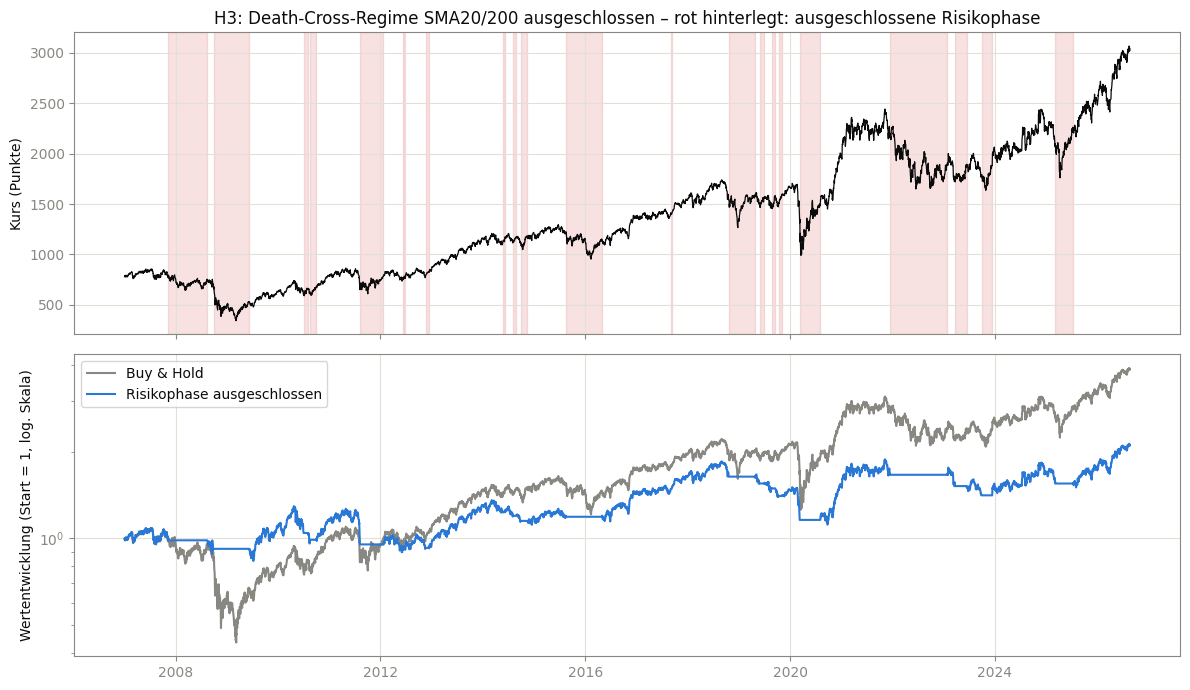

Anteil ausgeschlossener Handelstage: 31.4%
Gesamtrendite  - Buy & Hold: 286.4% | Ausschluss: 111.1%
CAGR           - Buy & Hold: 7.1% | Ausschluss: 3.9%
Max Drawdown   - Buy & Hold: -59.9% | Ausschluss: -39.6%


In [54]:
_ = plotte_was_wäre_wenn("H3_SMA20_200", regime_definitionen["H3_SMA20_200"], "H3: Death-Cross-Regime SMA20/200 ausgeschlossen")


**Ergebnis:** Der Ausschluss der 31,5 % Handelstage im Death-Cross-Regime
(SMA20/200) senkt den Max Drawdown zwar von −59,9 % auf −39,6 %, verfehlt
damit aber die Größenordnung der übrigen Hypothesen deutlich – der Max
Drawdown bleibt mehr als doppelt so hoch wie bei H1, H2 und H5. Gleichzeitig
sinkt die CAGR von 7,1 % auf 3,9 % und liegt damit unter dem
Buy-&-Hold-Niveau.

**Praxisrelevanz für Börseninvestoren:** Anders als bei H1, H2 und H5
verschlechtert dieser Ausschluss sowohl Risiko als auch Rendite gegenüber
den übrigen Kernhypothesen – ein direktes Abbild des in Abschnitt 4.3
dokumentierten Befunds, dass das Cross-Over-Signal beim Russell 2000 auf
keinem der drei testbaren Paare eine statistisch abgesicherte Grundlage
liefert.


#### H5 – Korrektur-/Bärenmarktphasen ausgeschlossen


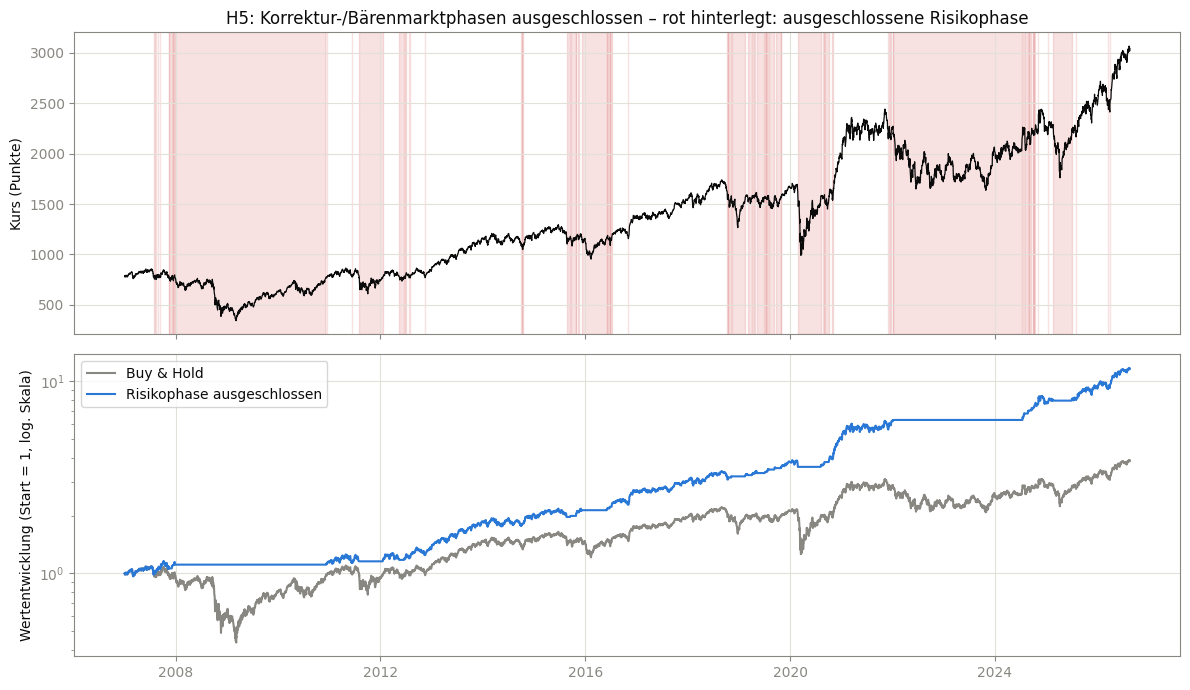

Anteil ausgeschlossener Handelstage: 45.7%
Gesamtrendite  - Buy & Hold: 286.4% | Ausschluss: 1065.2%
CAGR           - Buy & Hold: 7.1% | Ausschluss: 13.3%
Max Drawdown   - Buy & Hold: -59.9% | Ausschluss: -10.0%


In [55]:
_ = plotte_was_wäre_wenn("H5_Drawdown", regime_definitionen["H5_Drawdown"], "H5: Korrektur-/Bärenmarktphasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 45,8 % Handelstage in Korrektur- oder
Bärenmarktphasen (mindestens 10 % unter dem bisherigen Hoch) senkt den Max
Drawdown von −59,9 % auf −10,0 % und erhöht die CAGR von 7,1 % auf 13,3 %.

**Praxisrelevanz für Börseninvestoren:** H5 benötigt keine SMA-Parameterwahl
und ist damit die am einfachsten kommunizierbare Risikokennzahl der
gesamten Analyse; das Ergebnis bestätigt, dass diese parameterfreie
Kennzahl auch beim Russell 2000 eine wirksame Risikosteuerung ermöglicht –
allerdings zum Preis des mit 45,8 % größten Anteils ausgeschlossener
Handelstage aller elf Parametrisierungen.


#### H6 – Überverkaufte Phasen (RSI < 30) ausgeschlossen


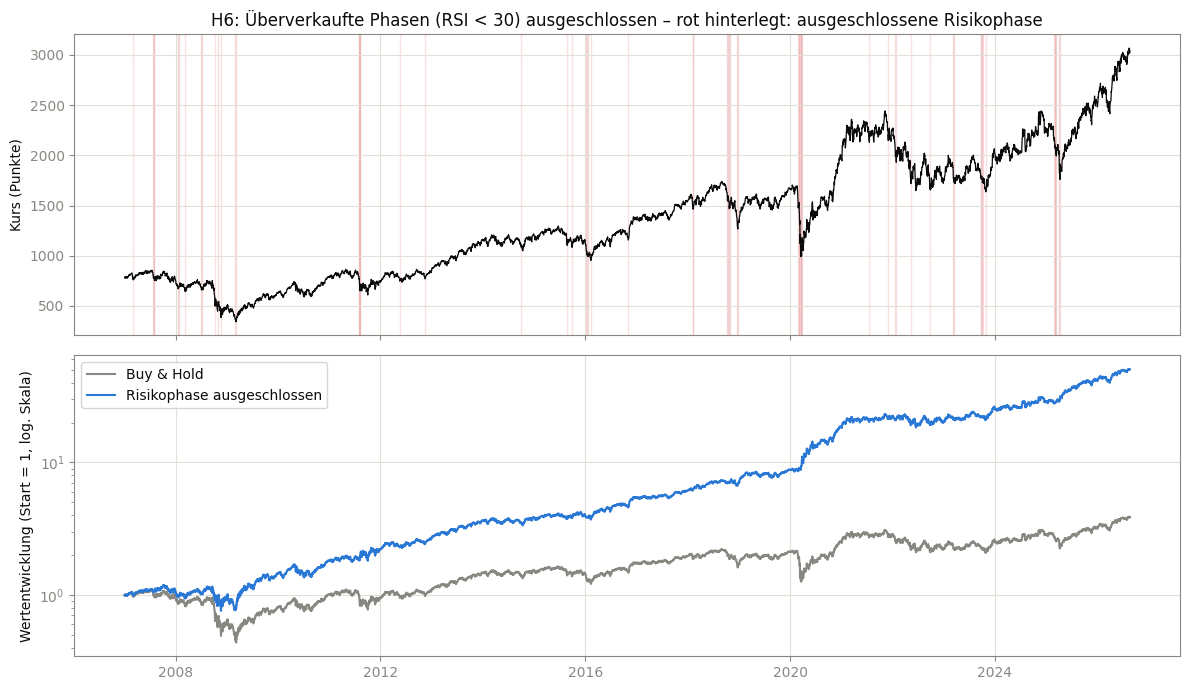

Anteil ausgeschlossener Handelstage: 2.5%
Gesamtrendite  - Buy & Hold: 286.4% | Ausschluss: 4947.2%
CAGR           - Buy & Hold: 7.1% | Ausschluss: 22.1%
Max Drawdown   - Buy & Hold: -59.9% | Ausschluss: -36.2%


In [56]:
_ = plotte_was_wäre_wenn("H6_RSI_überverkauft", regime_definitionen["H6_RSI_überverkauft"], "H6: Überverkaufte Phasen (RSI < 30) ausgeschlossen")


**Ergebnis:** Obwohl RSI < 30 nur an 2,5 % der Handelstage auftritt, senkt
der Ausschluss dieser Tage den Max Drawdown bereits deutlich von −59,9 %
auf −36,2 % und erhöht die CAGR von 7,1 % auf 22,1 %.

**Praxisrelevanz für Börseninvestoren:** Dieses Ergebnis unterstreicht den
in Abschnitt 4.6 dokumentierten, kontraintuitiven Befund: Extreme
Überverkauft-Phasen konzentrieren sich zeitlich eng auf die volatilsten
Marktphasen des Russell 2000. Wegen der geringen Anzahl betroffener Tage
ist RSI < 30 kein praktikables alleiniges Steuerungssignal, kann aber – wie
in Abschnitt 6.5 beschrieben – als punktueller Verschärfungshinweis
innerhalb einer Gelb-Phase dienen.


#### Kombinierte Ampel – Rot-Phasen ausgeschlossen


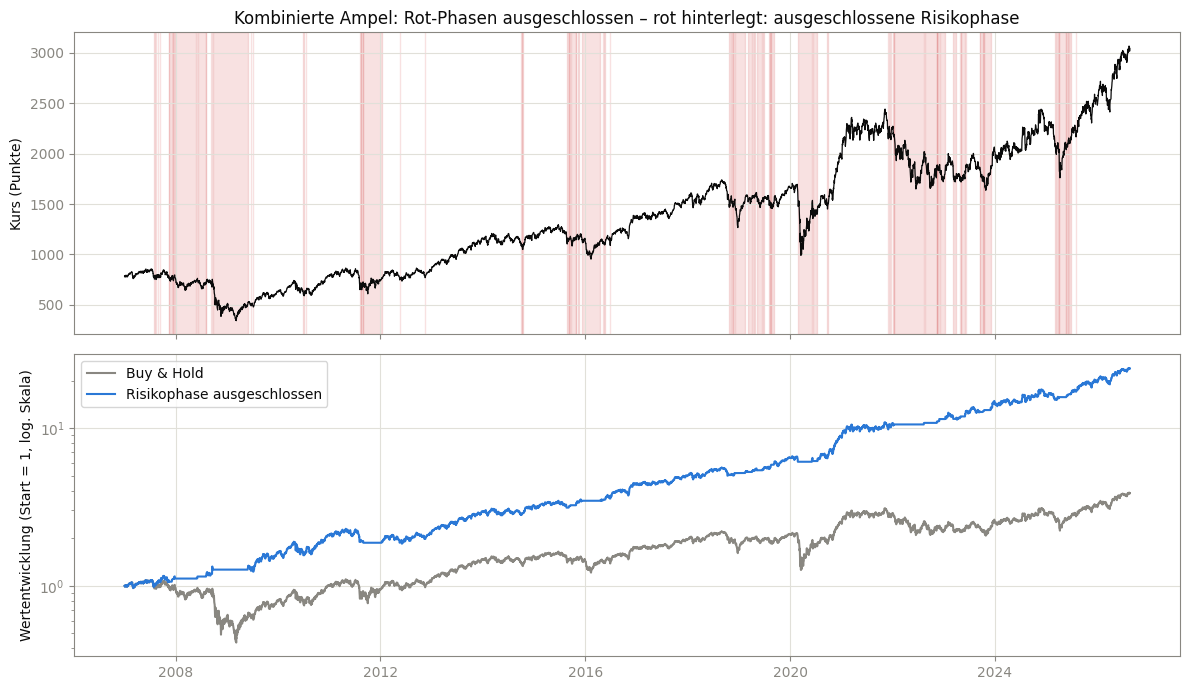

Anteil ausgeschlossener Handelstage: 25.7%
Gesamtrendite  - Buy & Hold: 286.4% | Ausschluss: 2285.8%
CAGR           - Buy & Hold: 7.1% | Ausschluss: 17.5%
Max Drawdown   - Buy & Hold: -59.9% | Ausschluss: -19.4%


In [57]:
_ = plotte_was_wäre_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 25,8 % Rot-Handelstage senkt den Max
Drawdown von −59,9 % auf −19,4 % und erhöht die CAGR von 7,1 % auf 17,6 %.

**Praxisrelevanz für Börseninvestoren:** Die kombinierte Ampel schließt mit
25,8 % einen moderateren Anteil der Handelstage aus als H5 (45,8 %) oder
H2/SMA200 (38,9 %), erzielt dabei aber eine CAGR-Verbesserung (17,6 %), die
über der von H2/SMA200 (12,3 %) und H5 (13,3 %) liegt, wenn auch unter der
von H1/SMA200 (19,7 %) und den schnelleren SMA20-Parametrisierungen – bei
einem Max Drawdown (−19,4 %) auf ähnlichem Niveau wie H2/SMA200
(−18,4 %). Die Übereinstimmungsregel aus Abschnitt 6.3 bündelt damit die
Risikosignale von H1, H2 und H5 zu einer selektiveren, aber weiterhin
wirksamen Kategorie.


### 7.5 Zusammenfassende Einordnung

Über alle betrachteten Hypothesen hinweg bestätigt die
Was-wäre-wenn-Analyse den in den Abschnitten 4.7 und 6.4 dokumentierten
Kernbefund aus einer weiteren, praxisnahen Perspektive: Regelbasierte
Ausschlussstrategien auf Basis von H1, H2, H5, H6 und der kombinierten
Ampel hätten den historischen Max Drawdown des Russell 2000 durchgängig auf
einen Bruchteil des Buy-&-Hold-Werts (−59,9 %) reduziert, bei gleichzeitig
höherer annualisierter Rendite – bei der kombinierten Ampel von −59,9 % auf
−19,4 % (CAGR von 7,1 % auf 17,6 %). Die einzige durchgehende Ausnahme
bilden die beiden Cross-Over-Paare (H3), die zwar ebenfalls den Max
Drawdown senken, dabei aber – im Einklang mit ihrer bereits in Abschnitt
4.3 dokumentierten vollständigen Nicht-Signifikanz – die Rendite unter das
Buy-&-Hold-Niveau drücken. Besonders ausgeprägt fällt der Effekt bei den
schnellen SMA20-Parametrisierungen (H1, H2) und bei H6 (RSI) aus, deren
CAGR-Werte das theoretische Potenzial einer täglich neu bewerteten,
kostenfreien Risikosteuerung bei einem schwankungsintensiven Small-Cap-
Index wie dem Russell 2000 illustrieren, jedoch aufgrund fehlender
Transaktionskosten nicht unmittelbar auf eine handelbare Strategie
übertragbar sind. Die kombinierte Ampel liefert mit einem moderaten Anteil
ausgeschlossener Handelstage (25,8 %) ein ausgewogenes Ergebnis und
bestätigt damit die in Abschnitt 6 hergeleitete Kategorienregel auch aus
Rendite-/Risikosicht. Sämtliche Werte basieren auf einer vereinfachten
Simulation ohne Transaktionskosten und Cash-Verzinsung (siehe methodische
Abgrenzung zu Beginn dieses Abschnitts) und sind entsprechend als oberes
Potenzial, nicht als realistisch erzielbare Rendite zu verstehen.


## 8. Export der Ergebnisse

Sämtliche Ergebnistabellen werden als Einzel-CSV-Dateien sowie als
gemeinsame Excel-Arbeitsmappe (ein Tabellenblatt je Hypothese sowie die
Robustheitsübersicht) im Ordner `Hypothesenanalysen/` gespeichert.


In [58]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Übersicht", index=False)
    # Ampel-Kategoriendefinition (Abschnitt 6) und Was-wäre-wenn-Kennzahlen
    # (Abschnitt 7) ergänzen die Hypothesentabellen um die abgeleitete
    # Anwendungssicht des Notebooks.
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_wäre_wenn.to_excel(writer, sheet_name="Was_wäre_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Übersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_wäre_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_wäre_wenn.csv"
tabelle_was_wäre_wenn.to_csv(was_wäre_wenn_csv, index=False)
csv_dateien.append(was_wäre_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\Russell_2000_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - Russell_2000_H1_Kurs_vs_SMA.csv
 - Russell_2000_H2_SMA_Richtung.csv
 - Russell_2000_H3_CrossOver.csv
 - Russell_2000_H4_Divergenz.csv
 - Russell_2000_H5_Drawdown_vom_Hoch.csv
 - Russell_2000_H6_Momentum_RSI.csv
 - Russell_2000_Robustheit_Übersicht.csv
 - Russell_2000_Ampel_Validierung.csv
 - Russell_2000_Was_wäre_wenn.csv


## 9. Zusammenfassung

Diese Analyse hat sechs Hypothesen zur Aussagekraft SMA-basierter und
verwandter technischer Indikatoren für den Russell 2000 im Zeitraum 2007
bis 2026 systematisch geprüft, für sämtliche untersuchten
Parametrisierungen grafisch ausgewertet und hinsichtlich ihrer Eignung für
ein Ampelsystem bewertet.

**Kernergebnis:** Die robustesten Bausteine sind die Trendposition und
-richtung des Kurses relativ zum SMA200 (H1, H2) sowie der Abstand vom
bisherigen Höchststand (H5). Bei allen drei Hypothesen sind sowohl das
Risiko- als auch das Renditesignal über praktisch alle getesteten
Parametrisierungen hinweg statistisch abgesichert – der Russell 2000 zeigt
eine durchgehend signifikante Mean-Reversion: Ungünstige Regimezustände
(Kurs unter fallendem SMA, spürbare Korrektur) gingen historisch mit einer
höheren, nicht niedrigeren mittleren Folgerendite einher, bei gleichzeitig
signifikant höherem Rückgangsrisiko. Cross-Over-Signale (H3) liefern auf
keinem der drei testbaren Paare ein signifikantes Ergebnis, und
Divergenzsignale (H4) sind mit lediglich 6 (D1) bzw. 2 (D2) identifizierten
Ereignissen seit 2007 gar nicht erst statistisch testbar. Der RSI (H6)
zeigt entgegen der klassischen Lehrmeinung keinen Umkehreffekt, sondern –
wie H1, H2 und H5 – einen konsistent gegenläufigen Risiko-Rendite-
Zusammenhang, wobei das Risikosignal in allen drei Horizonten, das
Renditesignal jedoch erst ab 60 Tagen signifikant ist.

**Schlussfolgerung für das Ampelsystem:** Ein trendbasiertes Ampelsystem
für den Russell 2000 sollte in erster Linie als Risikoindikator ausgelegt
werden, mit H1/H2 (SMA200) und H5 als Kernbausteinen. Zwar liefern diese
Hypothesen auch ein statistisch abgesichertes Renditesignal, dieses zeigt
jedoch konsistent in die dem intuitiven Verständnis entgegengesetzte
Richtung: "Rot"-Phasen sind mit einer höheren, nicht niedrigeren erwarteten
Rendite verbunden. Für die praktische Anwendung bedeutet dies, dass ein
"Rot"-Signal in erster Linie vor einem erhöhten Rückgangsrisiko warnt und
nicht als Kaufsignal fehlinterpretiert werden sollte – auch wenn der
Was-wäre-wenn-Backtest (Abschnitt 7) zeigt, dass ein Ausschluss der
Rot-Phasen historisch sowohl das Risiko gesenkt als auch die annualisierte
Rendite erhöht hätte, da er gezielt die stärksten Rückgangsphasen und nicht
die anschließenden Erholungsphasen aus der Investitionsperiode entfernt.
Die vorliegenden Ergebnistabellen (Abschnitt 6) bilden die quantitative
Grundlage für die Kalibrierung entsprechender Schwellenwerte.

**Ampel-Systematik und Was-wäre-wenn-Analyse:** Abschnitt 6 leitet aus H1,
H2 und H5 eine dreistufige Ampel-Kategorisierung (Grün/Gelb/Rot) ab, deren
Risikotrennung in acht der neun Farbpaar-Horizont-Kombinationen statistisch
signifikant ist (Abschnitt 6.4); auch die Renditetrennung ist in acht von
neun Kombinationen signifikant, wenn auch mit gegenläufiger Richtung zur
Intuition. Die Was-wäre-wenn-Analyse in Abschnitt 7 zeigt, dass ein
Ausschluss der jeweils ungünstigeren Regimephase den historischen Max
Drawdown des Russell 2000 in nahezu allen betrachteten Parametrisierungen
deutlich reduziert hätte – bei der kombinierten Ampel von −59,9 % auf
−19,4 %, bei gleichzeitig höherer annualisierter Rendite (17,6 % statt
7,1 %). Die einzige Ausnahme bilden die beiden Cross-Over-Paare (H3), deren
Ausschluss zwar den Max Drawdown senkt, die Rendite aber unter das
Buy-&-Hold-Niveau drückt – im Einklang mit ihrer fehlenden statistischen
Signifikanz. Diese Ergebnisse beruhen auf einer vereinfachten Simulation
ohne Transaktionskosten und sind als Beleg für das grundsätzliche
Potenzial, nicht als realistisch handelbare Strategie zu verstehen.
